In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')
sns.set(style="whitegrid")

## Load Data

In [2]:
try:
    base_dir = os.path.join(os.path.dirname(os.path.abspath(__file__)), "initial_data")
except NameError:
    base_dir = os.path.join(os.getcwd(), "..", "initial_data")
    base_dir = os.path.abspath(base_dir)

print("Looking for data in:", base_dir)
print("Path exists:", os.path.exists(base_dir))

# load f7
function_folder = os.path.join(base_dir, "function_7")
inputs = np.load(os.path.join(function_folder, "initial_inputs.npy"))
outputs = np.load(os.path.join(function_folder, "initial_outputs.npy"))

# reshape if needed
if inputs.ndim == 1:
    inputs = inputs.reshape(-1, 1)
if outputs.ndim == 1:
    outputs = outputs.reshape(-1, 1)

# create dataframe
input_cols = [f"X{j+1}" for j in range(inputs.shape[1])]
output_cols = [f"y{j+1}" for j in range(outputs.shape[1])]

df_f7 = pd.DataFrame(
    np.concatenate([inputs, outputs], axis=1),
    columns=input_cols + output_cols
)

print(f"Loaded function 7: shape = {df_f7.shape}, columns = {df_f7.columns.tolist()}")



Looking for data in: C:\Users\Hassa\OneDrive - Loughborough University\current\ML & AI\Capstone Project\initial_data
Path exists: True
Loaded function 7: shape = (30, 7), columns = ['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'y1']


In [3]:
week1_results = {"f7": ([0.799542, 0.949047, 0.887638, 0.265662, 0.631518, 0.349925], 0.026543407526137847)}

In [4]:
week2_results = {"f7": ([0.008500, 0.278800, 0.231600, 0.099300, 0.323000, 0.980800], 0.7653612109103147)}

In [5]:
week3_results = {"f7": ([0.000000, 0.189754, 0.123991, 0.253411, 0.406355, 0.251864], 0.4981320924641522)}

In [6]:
week4_results = {"f7": ([0.097366, 0.334928, 0.369818, 0.382418, 0.464971, 0.750762], 1.5985145628892428)}

In [7]:
week5_results = {"f7": ([0.053955, 0.757891, 0.608290, 0.473788, 0.364363, 0.971498], 0.32752252967109274)}

In [8]:
week6_results = {"f7": ([0.069772, 0.319669, 0.577421, 0.210909, 0.386068, 0.707262], 2.448290856114691)}

In [9]:
week7_results = {"f7": ([0.064462, 0.412641, 0.669514, 0.193009, 0.502173, 0.667338], 1.3516399930526517)}

In [10]:
week8_results = {"f7": ([0.186891, 0.934228, 0.522974, 0.187825, 0.066947, 0.841778], 0.13054782987236474)}

In [11]:
week9_results = {"f7": ([0.019978, 0.998379, 0.127323, 0.788041, 0.383133, 0.520111], 0.01764809003897648)}

In [12]:
week10_results = {"f7": ([0.125310, 0.292720, 0.563314, 0.153089, 0.354283, 0.706302], 2.55796551675835)}

In [13]:
week11_results = {"f7": ([0.044832, 0.301537, 0.610489, 0.251885, 0.351513, 0.697493], 2.5822487885107996)}

In [14]:
week12_results = {"f7": ([0.012792, 0.267813, 0.503058, 0.173435, 0.320692, 0.683622], 2.521894443305605)}

In [15]:
weekly_results = {
    "week1": week1_results,
    "week2": week2_results,
    "week3": week3_results,
    "week4": week4_results,
    "week5": week5_results,
    "week6": week6_results,
    "week7": week7_results,
    "week8": week8_results,
    "week9": week9_results,
    "week10": week10_results,
    "week11": week11_results,
    "week12": week12_results,
}

output_col = output_cols[0]   # this gives "y1"

# add weekly results to df_f7

for week, results in weekly_results.items():
    
    if "f7" not in results:
        continue
    
    inputs, output = results["f7"]
    
    # convert to numpy arrays
    inputs = np.array(inputs).reshape(1, -1)
    output = np.array([output]).reshape(1, -1)
    
    # build dataframe row with the same columns as df_f7
    df_new_row = pd.DataFrame(
        np.concatenate([inputs, output], axis=1),
        columns=["X1", "X2", "X3", "X4", "X5", "X6", "y1"]
    )
    
    # append to df_f7
    df_f7 = pd.concat([df_f7, df_new_row], ignore_index=True)
    
    # remove duplicates
    df_f7 = df_f7.drop_duplicates(ignore_index=True)

print("updated f7 shape:", df_f7.shape)


updated f7 shape: (42, 7)


In [16]:
print(df_f7)

          X1        X2        X3        X4        X5        X6        y1
0   0.272624  0.324495  0.897109  0.832951  0.154063  0.795864  0.604433
1   0.543003  0.924694  0.341567  0.646486  0.718440  0.343133  0.562753
2   0.090832  0.661529  0.065931  0.258577  0.963453  0.640265  0.007503
3   0.118867  0.615055  0.905816  0.855300  0.413631  0.585236  0.061424
4   0.630218  0.838097  0.680013  0.731895  0.526737  0.348429  0.273047
5   0.764919  0.255883  0.609084  0.218079  0.322943  0.095794  0.083747
6   0.057896  0.491672  0.247422  0.218118  0.420428  0.730970  1.364968
7   0.195252  0.079227  0.554580  0.170567  0.014944  0.107032  0.092645
8   0.642303  0.836875  0.021793  0.101488  0.683071  0.692416  0.017870
9   0.789943  0.195545  0.575623  0.073659  0.259049  0.051100  0.033565
10  0.528497  0.457424  0.360096  0.362046  0.816891  0.637476  0.073516
11  0.722615  0.011813  0.063646  0.165173  0.079244  0.359952  0.206310
12  0.075665  0.334502  0.132733  0.608312  0.91838

In [17]:
display(df_f7.describe().T)  

,count,mean,std,min,25%,50%,75%,max
X1,42.0,0.400213,0.331110,0.000000,0.079457,0.296217,0.725368,0.942451
X2,42.0,0.426464,0.270619,0.011813,0.258865,0.359191,0.598333,0.998379
X3,42.0,0.416278,0.292756,0.003635,0.128675,0.392146,0.610138,0.924571
X4,42.0,0.448032,0.298429,0.073659,0.197484,0.339056,0.750193,0.961017
X5,42.0,0.442167,0.276347,0.014944,0.260415,0.396212,0.671163,0.998655
X6,42.0,0.539759,0.268163,0.051100,0.348803,0.635590,0.724095,0.980800
y1,42.0,0.509869,0.767851,0.002701,0.022643,0.115527,0.594013,2.582249


## Feature vs y scatter plots


Feature vs y1 for f7


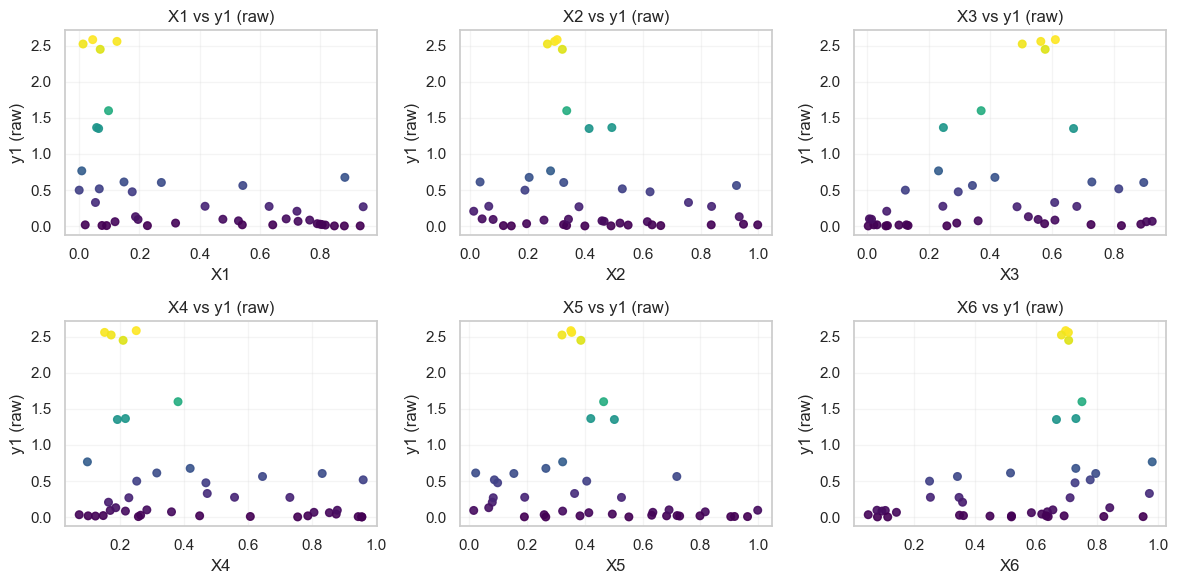

In [18]:
print("\nFeature vs y1 for f7")

# extract inputs and output for f7
input_cols_f7 = [c for c in df_f7.columns if c.startswith("X")]
X_f7 = df_f7[input_cols_f7].values
y_f7 = df_f7["y1"].values

# number of input features (df_f7 has 6)
n_features = X_f7.shape[1]
ncols = 3
nrows = int(np.ceil(n_features / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows))

# flatten axes safely
if nrows * ncols == 1:
    axes = [axes]
else:
    axes = axes.ravel().tolist()

# plot each feature
for j, col in enumerate(input_cols_f7):
    ax = axes[j]
    sc = ax.scatter(
        X_f7[:, j],
        y_f7,
        c=y_f7,
        cmap="viridis",
        s=30,
        alpha=0.9
    )
    ax.set_xlabel(col)
    ax.set_ylabel("y1 (raw)")
    ax.set_title(f"{col} vs y1 (raw)")
    ax.grid(alpha=0.2)

# hide unused axes
for k in range(n_features, len(axes)):
    axes[k].axis("off")

plt.tight_layout()
plt.show()


## Distribution Analysis

f7 – feature and output distributions


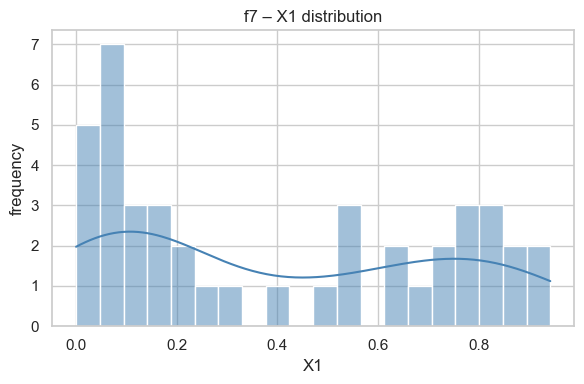

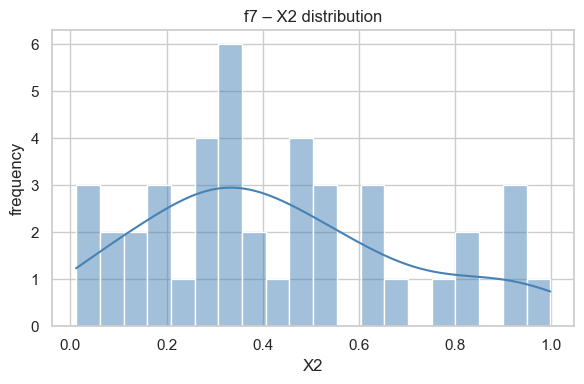

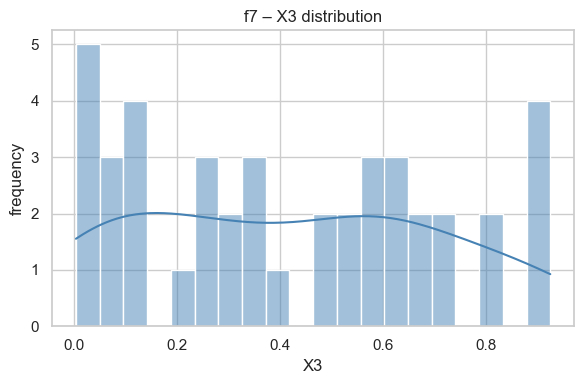

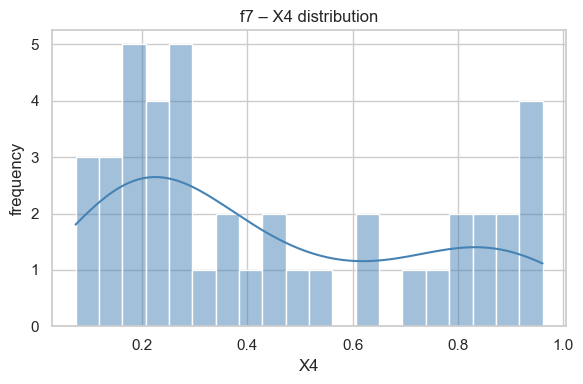

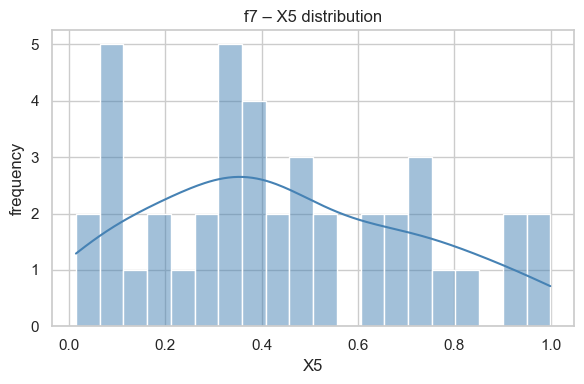

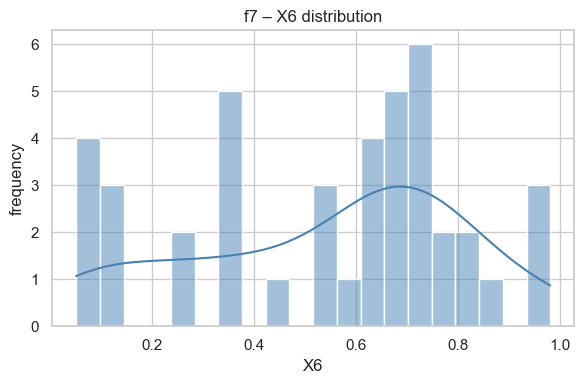

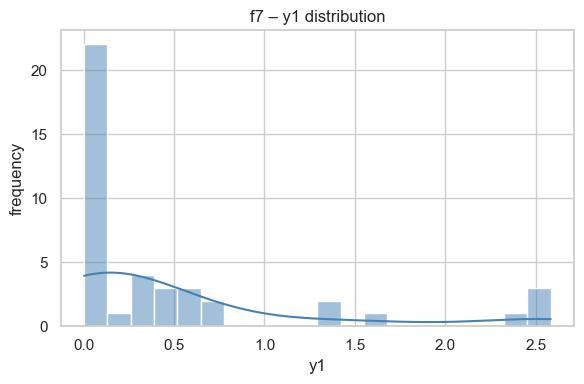

In [19]:
input_cols_f7 = [c for c in df_f7.columns if c.startswith("X")]
output_col_f7 = [c for c in df_f7.columns if c.startswith("y")][0]

print("f7 – feature and output distributions")

all_cols_raw_f7 = input_cols_f7 + [output_col_f7]

for col in all_cols_raw_f7:
    plt.figure(figsize=(6, 4))

    sns.histplot(
        df_f7[col],
        kde=True,
        bins=20,
        color="steelblue"
    )

    plt.title(f"f7 – {col} distribution")
    plt.xlabel(col)
    plt.ylabel("frequency")

    plt.tight_layout()
    plt.show()



## Y vs Instance Index

f7 – y vs instance index


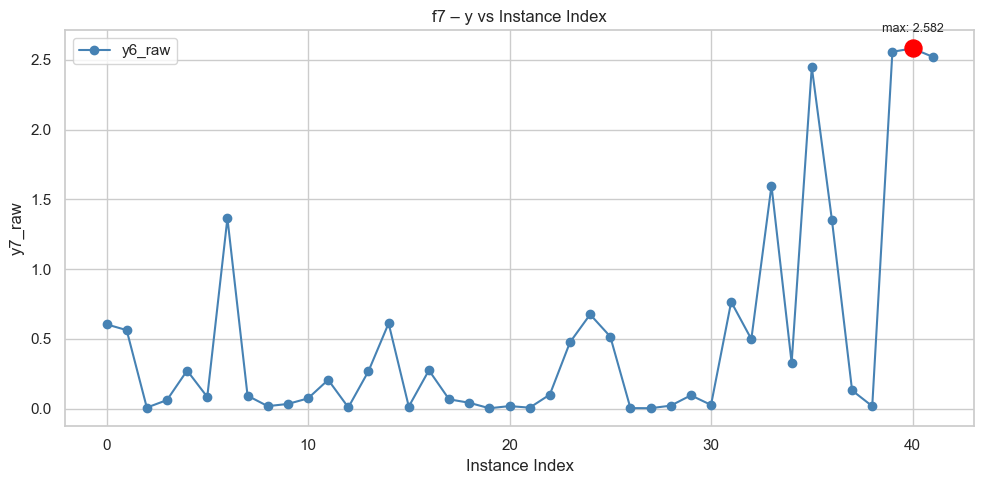

In [20]:
print("f7 – y vs instance index")

# clean copy of raw data
df_f7_plot = df_f7.copy()

# extract raw y
y_raw = df_f7_plot[output_col_f7].values
x = np.arange(len(y_raw))

plt.figure(figsize=(10, 5))

plt.plot(x, y_raw, marker="o", linestyle="-", color="steelblue", label="y6_raw")

# highlight maximum
max_idx = np.argmax(y_raw)
max_val = y_raw[max_idx]

plt.scatter(max_idx, max_val, s=150, color="red", zorder=5)
plt.annotate(
    f"max: {max_val:.3f}",
    (max_idx, max_val),
    textcoords="offset points",
    xytext=(0, 12),
    ha="center",
    fontsize=9
)

plt.title("f7 – y vs Instance Index")
plt.xlabel("Instance Index")
plt.ylabel("y7_raw")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()



## Pearson Correlation

f7 Pearson Correlation Matrix (raw y1)


,X1,X2,X3,X4,X5,X6,y1
X1,1.000000,-0.045263,-0.142378,0.064635,0.090591,-0.521222,-0.497136
X2,-0.045263,1.000000,0.034813,0.157032,0.207612,0.177930,-0.189792
X3,-0.142378,0.034813,1.000000,0.076025,-0.253866,0.119949,0.203634
X4,0.064635,0.157032,0.076025,1.000000,0.114743,-0.089813,-0.335944
X5,0.090591,0.207612,-0.253866,0.114743,1.000000,-0.016065,-0.213755
X6,-0.521222,0.177930,0.119949,-0.089813,-0.016065,1.000000,0.338811
y1,-0.497136,-0.189792,0.203634,-0.335944,-0.213755,0.338811,1.000000


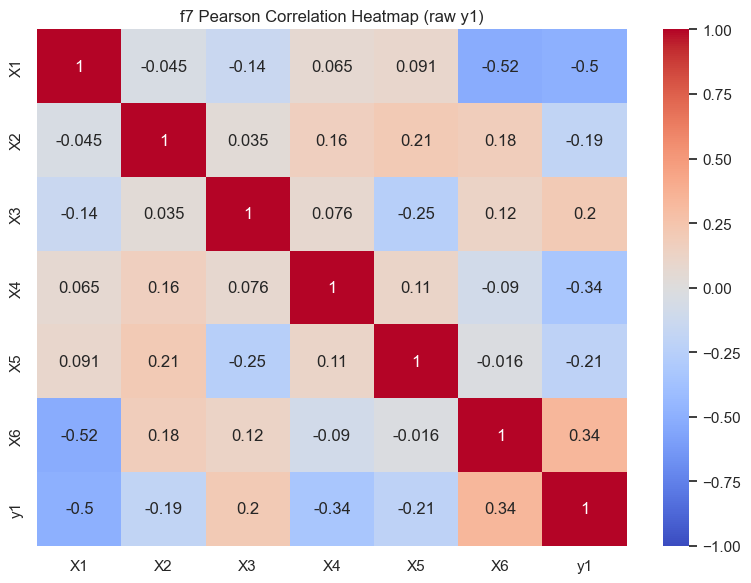

In [21]:
df_raw = df_f7.copy()

print("f7 Pearson Correlation Matrix (raw y1)")

corr_raw = df_raw.corr()
display(corr_raw)

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_raw,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)
plt.title("f7 Pearson Correlation Heatmap (raw y1)")
plt.tight_layout()
plt.show()

## Spearman Correlation

f7 Spearman Correlation Matrix (raw y1)


,X1,X2,X3,X4,X5,X6,y1
X1,1.000000,-0.044000,-0.117089,0.078681,0.043351,-0.468276,-0.516247
X2,-0.044000,1.000000,0.024228,0.225671,0.276720,0.156470,-0.215785
X3,-0.117089,0.024228,1.000000,0.051292,-0.222591,0.160846,0.310753
X4,0.078681,0.225671,0.051292,1.000000,0.122924,-0.041893,-0.282878
X5,0.043351,0.276720,-0.222591,0.122924,1.000000,-0.078195,-0.372984
X6,-0.468276,0.156470,0.160846,-0.041893,-0.078195,1.000000,0.377360
y1,-0.516247,-0.215785,0.310753,-0.282878,-0.372984,0.377360,1.000000


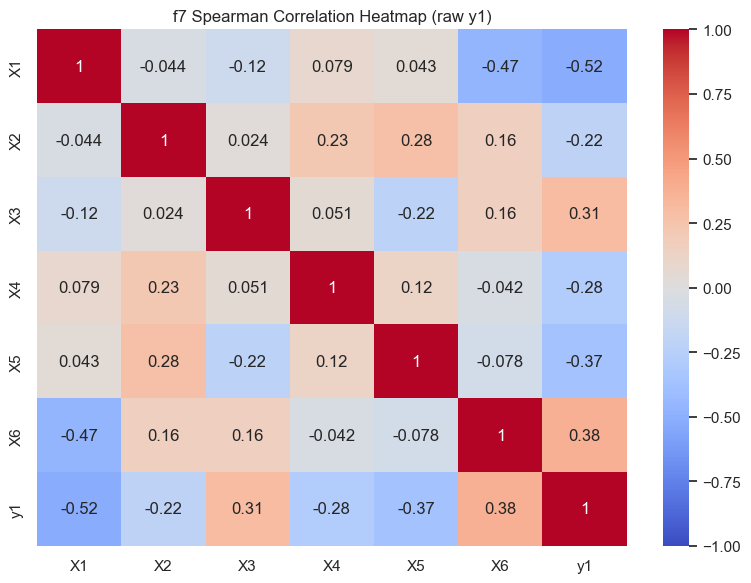

In [22]:
# spearman correlation with raw y1
df_raw = df_f7.copy()

print("f7 Spearman Correlation Matrix (raw y1)")

corr_raw_spearman = df_raw.corr(method="spearman")
display(corr_raw_spearman)

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_raw_spearman,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)
plt.title("f7 Spearman Correlation Heatmap (raw y1)")
plt.tight_layout()
plt.show()


## Kendall Correlation

f7 Kendall Correlation Matrix (raw y1)


,X1,X2,X3,X4,X5,X6,y1
X1,1.000000,-0.010453,-0.070848,0.049942,0.024390,-0.312427,-0.393728
X2,-0.010453,1.000000,0.019744,0.145180,0.198606,0.089431,-0.154472
X3,-0.070848,0.019744,1.000000,0.010453,-0.140534,0.112660,0.207898
X4,0.049942,0.145180,0.010453,1.000000,0.091754,-0.040650,-0.210221
X5,0.024390,0.198606,-0.140534,0.091754,1.000000,-0.052265,-0.240418
X6,-0.312427,0.089431,0.112660,-0.040650,-0.052265,1.000000,0.231127
y1,-0.393728,-0.154472,0.207898,-0.210221,-0.240418,0.231127,1.000000


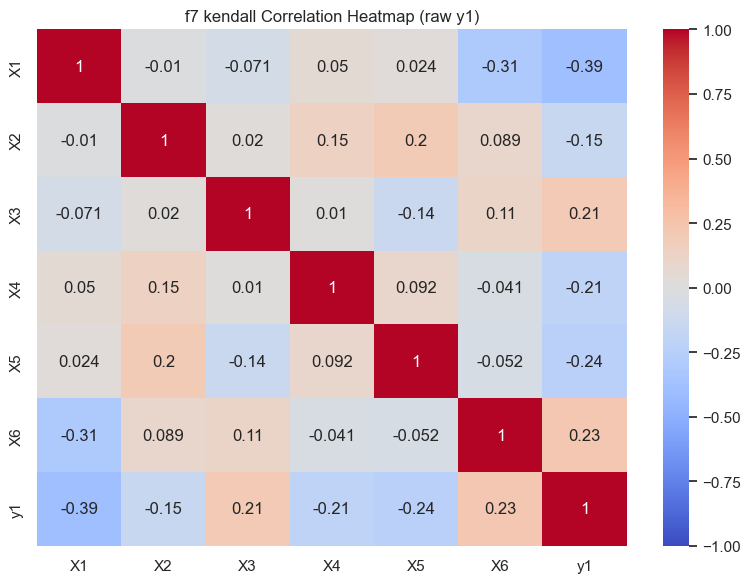

In [23]:
# Kendall correlation with raw y1
df_raw = df_f7.copy()

print("f7 Kendall Correlation Matrix (raw y1)")

corr_raw_kendall = df_raw.corr(method="kendall")
display(corr_raw_kendall)

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_raw_kendall,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)
plt.title("f7 kendall Correlation Heatmap (raw y1)")
plt.tight_layout()
plt.show()


## Mutual Information

In [24]:
from sklearn.feature_selection import mutual_info_regression

print("f7 — Mutual Information with Output")

df_f7_raw = df_f7.copy()

# define inputs and output
input_cols_f7 = [c for c in df_f7_raw.columns if c.startswith("X")]
output_col_f7 = "y1"

X_f7 = df_f7_raw[input_cols_f7].values
y_f7 = df_f7_raw[output_col_f7].values

# compute mutual information
mi_f7 = mutual_info_regression(X_f7, y_f7, random_state=42)

# build dataframe
mi_f7_df = pd.DataFrame({
    "Feature": input_cols_f7,
    "Mutual_Info": mi_f7
}).sort_values(by="Mutual_Info", ascending=False)

display(mi_f7_df)


f7 — Mutual Information with Output


,Feature,Mutual_Info
5,X6,0.372554
4,X5,0.244663
0,X1,0.184099
1,X2,0.132494
2,X3,0.128982
3,X4,0.102530


## Partial Correlation

In [25]:
!pip install pingouin
import pingouin as pg

print("f7 (Raw y1) — Partial Correlation")

df_f7_raw = df_f7.copy()

# define inputs and output
input_cols_f7 = [c for c in df_f7_raw.columns if c.startswith("X")]
output_col_f7 = "y1"

# compute partial correlations for each X feature
for x in input_cols_f7:
    covars = [c for c in input_cols_f7 if c != x]  # all other X's as covariates
    
    pcorr_raw_f7 = pg.partial_corr(
        data=df_f7_raw,
        x=x,
        y=output_col_f7,
        covar=covars
    )
    
    print(f"\nPartial correlation for {x}:")
    display(pcorr_raw_f7)


f7 (Raw y1) — Partial Correlation

Partial correlation for X1:


,n,r,CI95%,p-val
pearson,42,-0.401407,"[-0.64, -0.09]",0.013801



Partial correlation for X2:


,n,r,CI95%,p-val
pearson,42,-0.211884,"[-0.5, 0.12]",0.208046



Partial correlation for X3:


...

,n,r,CI95%,p-val
pearson,42,-0.327197,"[-0.59, -0.0]",0.048071



Partial correlation for X5:


,n,r,CI95%,p-val
pearson,42,-0.087028,"[-0.4, 0.24]",0.608529



Partial correlation for X6:


,n,r,CI95%,p-val
pearson,42,0.128747,"[-0.2, 0.43]",0.447596


## Sliced Inverse Regression


SIR for f7

leading SIR direction (most important 1D projection):
  X1: -0.5293
  X2: -0.1801
  X3: 0.3412
  X4: -0.3174
  X5: -0.5159
  X6: 0.4518

second SIR direction (additional structure):
  X1: -0.2911
  X2: -0.2262
  X3: -0.7132
  X4: -0.2641
  X5: 0.3892
  X6: 0.3663

leading eigenvalues:
  λ1 = 0.8567
  λ2 = 0.3489  (ratio λ2/λ1 = 0.407)

bootstrap stability of leading direction:
  mean angle: 46.41 deg
  std angle:  33.28 deg
  class:      moderately stable
  n_boot:     150


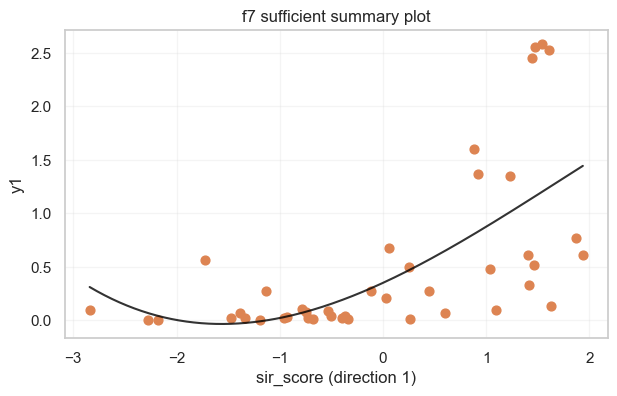

{'sir_dir1': array([-0.52932513, -0.18007396,  0.34116163, -0.31744784, -0.51585116,
         0.45179805]),
 'sir_dir2': array([-0.29106258, -0.22624304, -0.71323202, -0.26409278,  0.38923966,
         0.36625707]),
 'eigvals': array([0.85668181, 0.34886077, 0.29720445, 0.2438334 , 0.14544572,
        0.049343  ]),
 'scores': array([ 1.40885842, -1.72561754, -0.68046352,  0.59859118, -1.12996039,
        -0.53203829,  0.92545684,  1.09660241, -0.95512179, -0.3713679 ,
        -0.74344611,  0.0252862 , -0.3378134 ,  0.44699524,  1.93739988,
        -1.471228  , -0.11753073, -1.38169075, -0.50725006, -2.1804422 ,
        -1.33497994,  0.26363892, -0.78449523,  1.03582997,  0.05860439,
         1.46847894, -1.19463797, -2.27273163, -0.72579092, -2.84159057,
        -0.9272208 ,  1.86809185,  0.24850062,  0.88422538,  1.41898756,
         1.44355711,  1.22998939,  1.63309244, -0.39879285,  1.47587165,
         1.5396357 ,  1.60651649])}

In [26]:
from sklearn.preprocessing import StandardScaler
from sklearn.utils import resample


# Sliced Inverse Regression (SIR)
# SIR is a dimension-reduction method for regression.
# Instead of modelling y | x, it studies the inverse structure x | y.
# The idea:
#   1. Standardise X.
#   2. Slice y into quantile bins.
#   3. Compute the mean of X in each slice.
#   4. The covariance of these slice means reveals directions in X
#      that are most associated with changes in y.
#   5. Eigenvectors of this covariance give the "effective dimension"
#      directions (EDRs).
#   6. The first direction is the strongest 1D summary of X for predicting y.
#   7. The second direction often carries additional structure.
def sliced_inverse_regression(X, y, n_slices=8):
    # standardise X so all features have mean 0 and variance 1
    scaler = StandardScaler()
    Xs = scaler.fit_transform(X)

    n, p = Xs.shape

    # ensure number of slices is valid
    n_slices = min(max(2, int(n_slices)), max(2, n))

    # slice y into quantile bins
    quantiles = np.linspace(0.0, 1.0, n_slices + 1)
    bins = np.quantile(y, quantiles)
    bins[0] -= 1e-12
    bins[-1] += 1e-12
    slice_idx = np.digitize(y, bins) - 1

    # compute slice means of X and slice probabilities
    slice_means = np.zeros((n_slices, p))
    slice_probs = np.zeros(n_slices)
    for s in range(n_slices):
        mask = slice_idx == s
        if mask.sum() > 0:
            slice_means[s] = Xs[mask].mean(axis=0)
            slice_probs[s] = mask.sum() / n

    # between-slice covariance matrix
    # this captures how X changes as y moves across slices
    cov = np.zeros((p, p))
    for s in range(n_slices):
        m = slice_means[s].reshape(-1, 1)
        cov += slice_probs[s] * (m @ m.T)

    # eigen-decomposition of the covariance
    # eigenvectors = SIR directions
    eigvals, eigvecs = np.linalg.eigh(cov)
    idx = np.argsort(eigvals)[::-1]

    # normalise directions
    dirs = eigvecs[:, idx]
    dirs = dirs / (np.linalg.norm(dirs, axis=0) + 1e-12)

    # SIR scores = projection of X onto the first direction
    sir_scores = Xs @ dirs[:, 0]

    return dirs, sir_scores, scaler, eigvals[idx]



# Bootstrap stability of the leading SIR direction
# SIR can be unstable at small sample sizes.
# Bootstrap resampling gives a distribution of angles between
# the original SIR direction and bootstrap SIR directions.
# A small angle means stable; a large angle means unstable.
def sir_bootstrap_stability(X, y, n_slices=8, n_boot=100, random_state=0):
    rng = np.random.RandomState(random_state)

    # compute base SIR direction
    base_dirs, _, _, _ = sliced_inverse_regression(X, y, n_slices=n_slices)
    base = base_dirs[:, 0]

    angles = []

    for _ in range(n_boot):
        Xb, yb = resample(X, y, replace=True, random_state=rng)
        try:
            dirs_b, _, _, _ = sliced_inverse_regression(Xb, yb, n_slices=n_slices)
            db = dirs_b[:, 0]

            # angle between base direction and bootstrap direction
            cosang = np.clip(
                np.dot(base, db) /
                (np.linalg.norm(base) * np.linalg.norm(db) + 1e-12),
                -1.0, 1.0
            )
            angles.append(np.arccos(cosang))
        except Exception:
            continue

    angles = np.array(angles)
    mean_deg = np.degrees(np.nanmean(angles))
    std_deg = np.degrees(np.nanstd(angles))

    # stability classification
    if mean_deg < 30:
        cls = "stable"
    elif mean_deg < 60:
        cls = "moderately stable"
    else:
        cls = "unstable"

    return {
        "mean_angle_deg": mean_deg,
        "std_angle_deg": std_deg,
        "class": cls,
        "n_boot": len(angles)
    }



# Main SIR analysis for df_f7
# Includes:
#   - leading and second SIR directions
#   - bootstrap stability classification
#   - polynomial smoothing on the sufficient summary plot

def run_sir_f7(df_f7, n_slices=8, bootstrap_checks=True):
    input_cols = [c for c in df_f7.columns if c.startswith("X")]
    output_col = "y1"

    X = df_f7[input_cols].values.astype(float)
    y = df_f7[output_col].values.astype(float)

    # compute SIR directions
    dirs, sir_scores, scaler, eigvals = sliced_inverse_regression(X, y, n_slices=n_slices)
    sir_dir1 = dirs[:, 0]
    sir_dir2 = dirs[:, 1]

    print("\nSIR for f7")

    # print leading direction
    print("\nleading SIR direction (most important 1D projection):")
    for col, v in zip(input_cols, sir_dir1):
        print(f"  {col}: {v:.4f}")

    # print second direction
    print("\nsecond SIR direction (additional structure):")
    for col, v in zip(input_cols, sir_dir2):
        print(f"  {col}: {v:.4f}")

    # eigenvalues show how much variance each direction explains
    print("\nleading eigenvalues:")
    print(f"  λ1 = {eigvals[0]:.4f}")
    print(f"  λ2 = {eigvals[1]:.4f}  (ratio λ2/λ1 = {eigvals[1]/eigvals[0]:.3f})")

    # bootstrap stability
    if bootstrap_checks:
        stab = sir_bootstrap_stability(X, y, n_slices=n_slices, n_boot=150)
        print("\nbootstrap stability of leading direction:")
        print(f"  mean angle: {stab['mean_angle_deg']:.2f} deg")
        print(f"  std angle:  {stab['std_angle_deg']:.2f} deg")
        print(f"  class:      {stab['class']}")
        print(f"  n_boot:     {stab['n_boot']}")

    # sufficient summary plot
    plt.figure(figsize=(7,4))
    plt.scatter(sir_scores, y, c="C1", s=40)
    plt.xlabel("sir_score (direction 1)")
    plt.ylabel("y1")
    plt.title("f7 sufficient summary plot")
    plt.grid(alpha=0.2)

    # polynomial smoothing (degree 3)
    try:
        coeffs = np.polyfit(sir_scores, y, 3)
        xs = np.linspace(sir_scores.min(), sir_scores.max(), 200)
        ys = np.polyval(coeffs, xs)
        plt.plot(xs, ys, color="black", linewidth=1.5, alpha=0.8)
    except Exception:
        pass

    plt.show()

    return {
        "sir_dir1": sir_dir1,
        "sir_dir2": sir_dir2,
        "eigvals": eigvals,
        "scores": sir_scores
    }


run_sir_f7(df_f7, n_slices=8, bootstrap_checks=True)

## 2D Geodesic Embedding

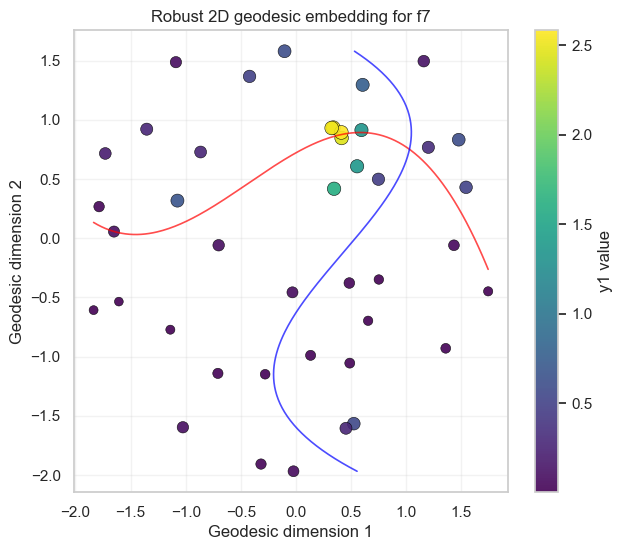

{'embedding': array([[ 1.4763485 ,  0.83150544],
        [ 0.52455427, -1.56707286],
        [ 0.65448246, -0.69806738],
        [ 1.43282915, -0.06018813],
        [ 0.45339676, -1.60603699],
        [-1.65041215,  0.05549444],
        [ 0.55460455,  0.60701809],
        [-1.0888795 ,  1.48645385],
        [ 0.48802256, -1.05582197],
        [-1.78567987,  0.26642414],
        [-0.03164762, -0.45769079],
        [-1.72941554,  0.7152713 ],
        [ 0.75180891, -0.34942447],
        [-0.8648336 ,  0.72744659],
        [-0.10336694,  1.57866251],
        [-0.27950318, -1.14972157],
        [-1.35360407,  0.92036656],
        [-0.02231027, -1.96905595],
        [ 0.48400225, -0.37912078],
        [-1.6063095 , -0.5361721 ],
        [ 0.13272238, -0.99000661],
        [ 1.74324054, -0.44935541],
        [-0.7011073 , -0.05995712],
        [ 0.74832978,  0.49750505],
        [-1.07516512,  0.31705772],
        [ 1.54298632,  0.42934001],
        [-1.13945045, -0.7733509 ],
        [-1.835

In [27]:
from sklearn.metrics import pairwise_distances
from sklearn.manifold import MDS


def robust_isomap_2d(X, k=6, eps_factor=0.25):
    """
    Robust Isomap-like embedding that never fails.
    Builds a hybrid graph:
      - k-NN edges
      - epsilon-radius edges (eps = eps_factor * median distance)
    Ensures graph connectivity and computes geodesic distances.
    Uses classical MDS to obtain a 2D embedding.
    """

    # standardise X
    scaler = StandardScaler()
    Xs = scaler.fit_transform(X)

    # pairwise distances
    D = pairwise_distances(Xs)

    # k-NN graph
    n = len(X)
    knn_graph = np.full((n, n), np.inf)
    for i in range(n):
        idx = np.argsort(D[i])[1:k+1]
        knn_graph[i, idx] = D[i, idx]
        knn_graph[idx, i] = D[idx, i]

    # epsilon graph to guarantee connectivity
    eps = eps_factor * np.median(D)
    eps_graph = np.where(D <= eps, D, np.inf)

    # hybrid graph
    G = np.minimum(knn_graph, eps_graph)

    # Floyd–Warshall for geodesic distances
    geo = G.copy()
    for k in range(n):
        geo = np.minimum(geo, geo[:, k][:, None] + geo[k, :][None, :])

    # classical MDS on geodesic distances
    mds = MDS(n_components=2, dissimilarity="precomputed", random_state=0)
    emb = mds.fit_transform(geo)

    # standardise embedding
    emb = (emb - emb.mean(axis=0)) / (emb.std(axis=0) + 1e-12)

    return emb, scaler, geo


def run_isomap_f7(df_f7):
    input_cols = [c for c in df_f7.columns if c.startswith("X")]
    X = df_f7[input_cols].values.astype(float)
    y = df_f7["y1"].values.astype(float)

    ranks = np.argsort(np.argsort(y))
    sizes = 40 + 60 * (ranks / ranks.max())

    # robust embedding
    emb, scaler, geo = robust_isomap_2d(X, k=6, eps_factor=0.25)

    # plot
    plt.figure(figsize=(7, 6))
    sc = plt.scatter(
        emb[:, 0], emb[:, 1],
        c=y, s=sizes,
        cmap="viridis",
        alpha=0.9,
        edgecolor="black",
        linewidth=0.4
    )
    plt.xlabel("Geodesic dimension 1")
    plt.ylabel("Geodesic dimension 2")
    plt.title("Robust 2D geodesic embedding for f7")
    plt.grid(alpha=0.25)
    plt.colorbar(sc, label="y1 value")

    # polynomial smoothing along each axis
    try:
        coeffs_x = np.polyfit(emb[:, 0], y, 3)
        xs = np.linspace(emb[:, 0].min(), emb[:, 0].max(), 200)
        ys = np.polyval(coeffs_x, xs)
        plt.plot(xs, ys, color="red", linewidth=1.2, alpha=0.7)
    except Exception:
        pass

    try:
        coeffs_y = np.polyfit(emb[:, 1], y, 3)
        ys2 = np.linspace(emb[:, 1].min(), emb[:, 1].max(), 200)
        xs2 = np.polyval(coeffs_y, ys2)
        plt.plot(xs2, ys2, color="blue", linewidth=1.2, alpha=0.7)
    except Exception:
        pass

    plt.show()

    return {"embedding": emb, "geodesic_distances": geo, "scaler": scaler}


run_isomap_f7(df_f7)

## K means Clustering


K-means clustering for df_f7 (focused high-value analysis)

high-value cluster: 1
mean y1 in this cluster: 1.345166

members of high-value cluster (row indices):
[6, 23, 31, 33, 34, 35, 36, 37, 38, 39, 40, 41]

centroid of high-value cluster (6D):
         X1        X2        X3        X4        X5       X6
0  0.076478  0.501225  0.443897  0.300114  0.336278  0.74884

within-cluster variance per dimension:
  dimension  within_cluster_variance
0        X1                 0.003235
1        X2                 0.064297
2        X3                 0.029909
3        X4                 0.035233
4        X5                 0.015586
5        X6                 0.015180


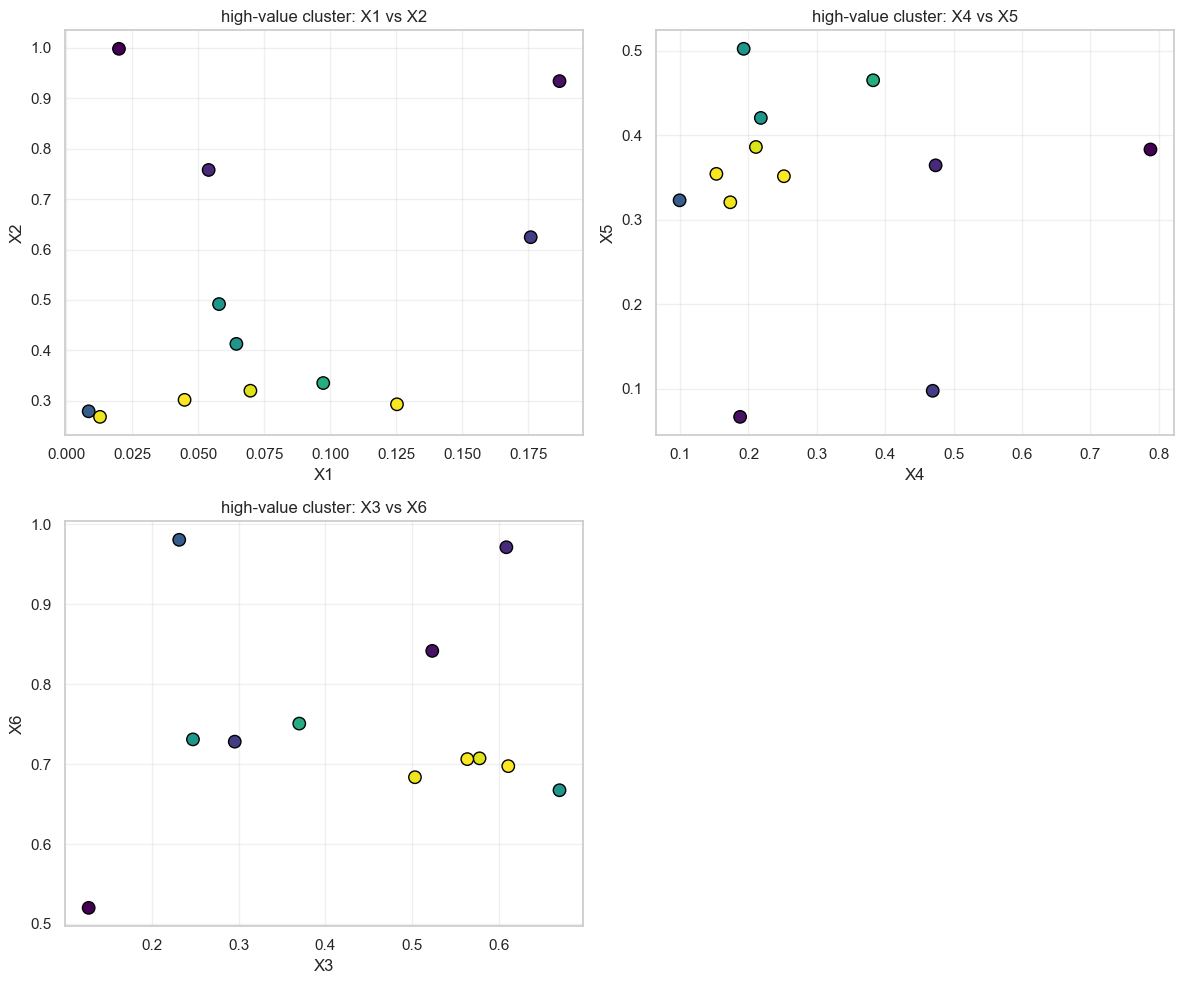

In [28]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# focused k-means clustering for df_f7 with emphasis on the high-value cluster

print("\nK-means clustering for df_f7 (focused high-value analysis)")

# extract input and output columns
input_cols = [col for col in df_f7.columns if col.startswith("X")]
output_col = "y1"

# convert to arrays
X_f7 = df_f7[input_cols].values.astype(float)
y_f7 = df_f7[output_col].values.astype(float)

# run k-means with k=6 (confirmed optimal)
k = 6
kmeans = KMeans(n_clusters=k, random_state=42)
kmeans.fit(X_f7)

# assign cluster labels
labels = kmeans.labels_
df_f7["cluster"] = labels

# compute mean y1 for each cluster
cluster_means = df_f7.groupby("cluster")[output_col].mean()

# identify the cluster with the highest mean y1
high_cluster = cluster_means.idxmax()
print(f"\nhigh-value cluster: {high_cluster}")
print(f"mean y1 in this cluster: {cluster_means[high_cluster]:.6f}")

# list the row indices belonging to the high-value cluster
members = df_f7.index[df_f7["cluster"] == high_cluster].tolist()
print("\nmembers of high-value cluster (row indices):")
print(members)

# extract the centroid of the high-value cluster
centroid = kmeans.cluster_centers_[high_cluster]
centroid_df = pd.DataFrame([centroid], columns=input_cols)
print("\ncentroid of high-value cluster (6D):")
print(centroid_df)

# compute within-cluster variance for each dimension
X_cluster = X_f7[df_f7["cluster"] == high_cluster]
var_within = X_cluster.var(axis=0)

var_df = pd.DataFrame({
    "dimension": input_cols,
    "within_cluster_variance": var_within
})
print("\nwithin-cluster variance per dimension:")
print(var_df)

# scatter plots showing only the high-value cluster members
plt.figure(figsize=(12, 10))

# choose three informative feature pairs
pairs = [(0, 1), (3, 4), (2, 5)]  # X1 vs X2, X4 vs X5, X3 vs X6

for i, (a, b) in enumerate(pairs, 1):
    plt.subplot(2, 2, i)
    plt.scatter(
        X_cluster[:, a],
        X_cluster[:, b],
        c=y_f7[df_f7["cluster"] == high_cluster],
        cmap="viridis",
        s=80,
        edgecolor="black"
    )
    plt.xlabel(input_cols[a])
    plt.ylabel(input_cols[b])
    plt.title(f"high-value cluster: {input_cols[a]} vs {input_cols[b]}")
    plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()



## Active Subspace Detection via Gradient-Based Dimension Reduction

**Reference:** Constantine, P.G., Dow, E. and Wang, Q. (2014) 'Active subspace methods in theory and practice: applications to kriging surfaces', SIAM Journal on Scientific Computing, 36(4), pp. A1500–A1524. Available at: https://doi.org/10.1137/130916138

- Used for f7 because the function has 6 input dimensions but the EDA consistently shows only 3 dimensions (X1, X5, X6) carrying meaningful signal, and active subspace detection quantifies how many effective dimensions the function has near the current best by decomposing the average squared gradient matrix, directly informing whether the trust region should be a hyper-rectangle or an oriented ellipsoid aligned with the true directions of variation.


active subspace detection
eigenvalues (top 4): [5.2934 1.2429 0.6091 0.1111]
consecutive eigenvalue ratios: [0.2348 0.49   0.1825]
effective dimensionality estimate:
  function appears effectively 3d (ratio 0.182 < 0.20)

leading active subspace direction (w1):
  X1: -0.0281
  X2: -0.4923
  X3: 0.0055
  X4: -0.0884
  X5: -0.8403
  X6: -0.2071

second active subspace direction (w2):
  X1: -0.0349
  X2: -0.0154
  X3: 0.0034
  X4: 0.0284
  X5: 0.2458
  X6: -0.9681


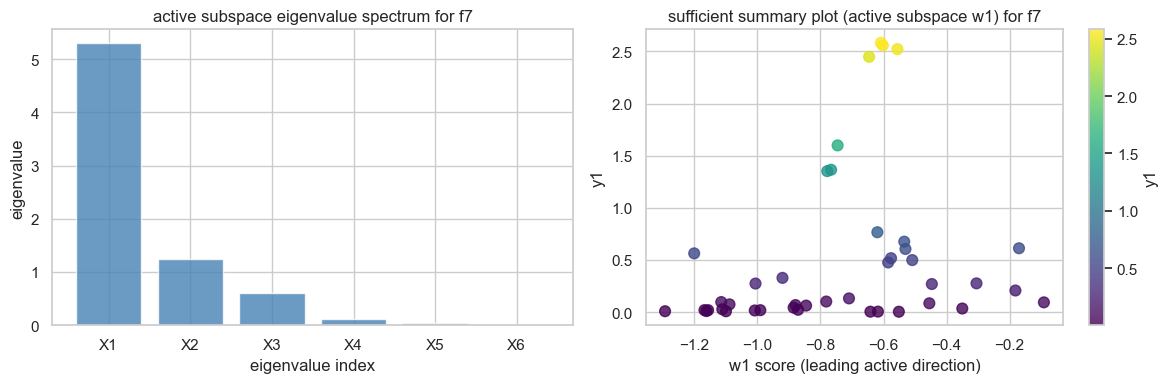

In [29]:
from sklearn.gaussian_process import GaussianProcessRegressor as GPR
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel as C
from sklearn.linear_model import LinearRegression

# method: active subspace detection via finite differences
# source: high-dimensional bo survey (neurips 2024) and dimension_reduction.pdf
# estimates the matrix of average squared directional derivatives
# using finite differences on existing observations
# eigenvalues rank how much variance each direction explains
# eigenvectors define the active subspace directions

def compute_active_subspace(df, feature_cols, target_col, delta=0.05):
    """
    estimates the active subspace of the function using finite differences.
    the active subspace is the low-dimensional subspace where the function
    varies most, identified by the dominant eigenvectors of the matrix
    c = e[grad f * grad f^t], approximated from finite differences.

    parameters
    ----------
    df : dataframe containing features and target
    feature_cols : list of input column names
    target_col : output column name
    delta : finite difference step size (default 0.05)
    """

    X = df[feature_cols].values
    y = df[target_col].values
    n, d = X.shape

    # fit a gp to approximate the function for finite difference computation
    # matern 2.5 with ard is used to respect per-dimension length scales
    kernel = C(1.0, (1e-2, 1e2)) * Matern(
        length_scale=np.ones(d),
        length_scale_bounds=[(0.05, 5.0)] * d,
        nu=2.5
    ) + WhiteKernel(noise_level=1e-4, noise_level_bounds=(1e-6, 0.1))

    gp = GPR(kernel=kernel, normalize_y=True, n_restarts_optimizer=5)
    gp.fit(X, y)

    # compute finite difference gradient at each observed point
    # grad_f[i, j] = (f(x + delta*e_j) - f(x - delta*e_j)) / (2*delta)
    # this is the central difference approximation of the partial derivative
    grad_matrix = np.zeros((n, d))

    for i in range(n):
        for j in range(d):
            x_plus = X[i].copy()
            x_minus = X[i].copy()
            x_plus[j] = np.clip(X[i, j] + delta, 0.0, 1.0)
            x_minus[j] = np.clip(X[i, j] - delta, 0.0, 1.0)

            f_plus = gp.predict(x_plus.reshape(1, -1))[0]
            f_minus = gp.predict(x_minus.reshape(1, -1))[0]

            # use actual delta after clipping
            actual_delta = x_plus[j] - x_minus[j]
            if actual_delta > 1e-8:
                grad_matrix[i, j] = (f_plus - f_minus) / actual_delta
            else:
                grad_matrix[i, j] = 0.0

    # active subspace matrix c = (1/n) * sum_i grad_i * grad_i^t
    # shape (d, d), symmetric positive semidefinite
    C_matrix = (grad_matrix.T @ grad_matrix) / n

    # eigendecomposition: eigenvalues in descending order
    eigenvalues, eigenvectors = np.linalg.eigh(C_matrix)
    sort_idx = np.argsort(eigenvalues)[::-1]
    eigenvalues = eigenvalues[sort_idx]
    eigenvectors = eigenvectors[:, sort_idx]

    # eigenvalue ratio: consecutive ratio < 0.1 indicates effective dimensionality
    # e.g. if eigenvalue[1] / eigenvalue[0] < 0.1, function is effectively 1d
    ratios = eigenvalues[1:] / (eigenvalues[:-1] + 1e-12)

    print("\nactive subspace detection")
    print(f"eigenvalues (top {min(d, 4)}): {eigenvalues[:4].round(4)}")
    print(f"consecutive eigenvalue ratios: {ratios[:3].round(4)}")
    print("effective dimensionality estimate:")
    for k in range(1, d):
        if ratios[k-1] < 0.20:
            print(f"  function appears effectively {k}d (ratio {ratios[k-1]:.3f} < 0.20)")
            break
    else:
        print(f"  function appears effectively {d}d (no clear eigenvalue gap)")

    print("\nleading active subspace direction (w1):")
    for i, col in enumerate(feature_cols):
        print(f"  {col}: {eigenvectors[i, 0]:.4f}")

    print("\nsecond active subspace direction (w2):")
    for i, col in enumerate(feature_cols):
        print(f"  {col}: {eigenvectors[i, 1]:.4f}")

    # plot eigenvalue spectrum
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].bar(range(1, d+1), eigenvalues, color="steelblue", alpha=0.8)
    axes[0].set_xlabel("eigenvalue index")
    axes[0].set_ylabel("eigenvalue")
    axes[0].set_title("active subspace eigenvalue spectrum for f7")
    axes[0].set_xticks(range(1, d+1))
    axes[0].set_xticklabels(feature_cols)

    # sufficient summary plot along leading active subspace direction
    active_scores = X @ eigenvectors[:, 0]
    axes[1].scatter(active_scores, y, c=y, cmap="viridis", s=60, alpha=0.8)
    axes[1].set_xlabel("w1 score (leading active direction)")
    axes[1].set_ylabel("y1")
    axes[1].set_title("sufficient summary plot (active subspace w1) for f7")
    plt.colorbar(axes[1].collections[0], ax=axes[1], label="y1")

    plt.tight_layout()
    plt.show()

    return eigenvalues, eigenvectors, grad_matrix


eigenvalues_f7, eigenvectors_f7, grad_f7 = compute_active_subspace(
    df_f7,
    feature_cols=["X1", "X2", "X3", "X4", "X5", "X6"],
    target_col="y1"
)

## Local Linear Embedding of the High-Value Neighbourhood


**Reference:** Roweis, S.T. and Saul, L.K. (2000) 'Nonlinear dimensionality reduction by locally linear embedding', Science, 290(5500), pp. 2323–2326. Available at: https://doi.org/10.1126/science.290.5500.2323

- Used for f7 because the global SIR direction has bootstrap stability angles between 53 and 79 degrees across weeks, indicating it is only moderately reliable, and a local linear fit restricted to the top-10 observations produces a gradient direction specific to the confirmed high-value neighbourhood rather than the full dataset, making it more trustworthy for acquisition guidance in the exploitation phase.


local linear gradient (top 10 observations)
y range in local neighbourhood: [0.6115, 2.5822]
observations included:
  idx=40: y=2.5822
  idx=39: y=2.5580
  idx=41: y=2.5219
  idx=35: y=2.4483
  idx=33: y=1.5985
  idx=6: y=1.3650
  idx=36: y=1.3516
  idx=31: y=0.7654
  idx=24: y=0.6751
  idx=14: y=0.6115

local linear model r2: 0.4640
local gradient direction (standardised coefficients):
  X1: -0.0635  (normalised: -0.0458)  -> decrease
  X2: -0.6802  (normalised: -0.4912)  -> decrease
  X3: -0.1716  (normalised: -0.1239)  -> decrease
  X4: -0.4232  (normalised: -0.3056)  -> decrease
  X5: 0.9761  (normalised: 0.7048)  -> increase
  X6: -0.5383  (normalised: -0.3887)  -> decrease

local gradient vs sir: positive = agree, negative = disagree
  X1: dot product = 0.0269  (agree)
  X2: dot product = 0.0286  (agree)
  X3: dot product = -0.0224  (DISAGREE)
  X4: dot product = 0.1069  (agree)
  X5: dot product = -0.3253  (DISAGREE)
  X6: dot product = -0.2069  (DISAGREE)


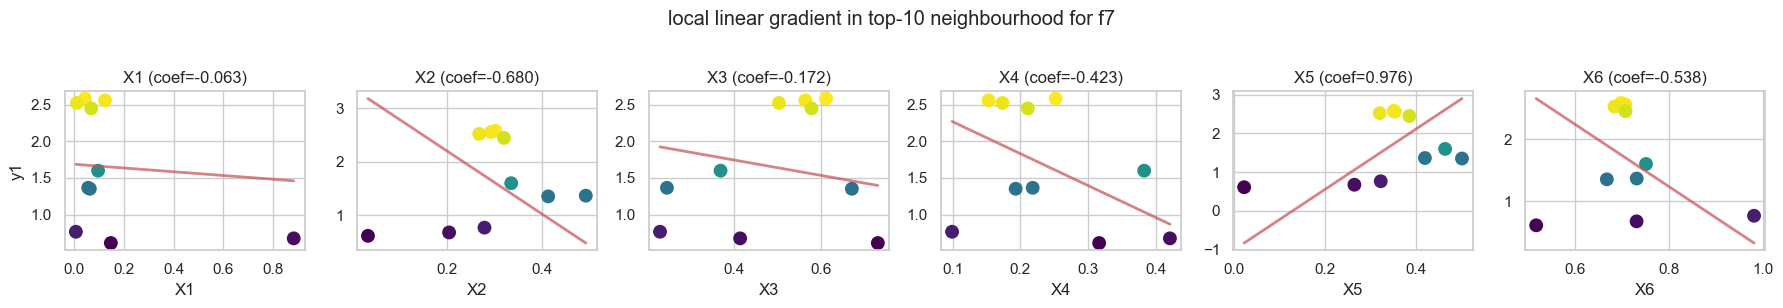

In [30]:
# method: local linear embedding of high-value neighbourhood
# source: dimension_reduction.pdf and latent_space.pdf
# fits a local linear model to the top-n observations only
# the coefficients give the local gradient direction near the peak
# more reliable than sir at small n because it focuses on the
# high-value region rather than the full dataset


def local_linear_gradient(df, feature_cols, target_col, top_n=10):
    """
    fits a local linear model to the top-n observations by y value.
    the regression coefficients approximate the local gradient direction
    in the neighbourhood of the current best observations.
    this direction can replace or augment the sir direction as the
    acquisition boost in the trust region ensemble.

    parameters
    ----------
    df : dataframe containing features and target
    feature_cols : list of input column names
    target_col : output column name
    top_n : number of top observations to include in local fit
    """

    # select top-n observations by y value
    df_sorted = df.nlargest(top_n, target_col)
    X_local = df_sorted[feature_cols].values
    y_local = df_sorted[target_col].values

    print(f"\nlocal linear gradient (top {top_n} observations)")
    print(f"y range in local neighbourhood: [{y_local.min():.4f}, {y_local.max():.4f}]")
    print("observations included:")
    for idx in df_sorted.index:
        row = df_sorted.loc[idx]
        print(f"  idx={idx}: y={row[target_col]:.4f}")

    # standardise inputs for comparable coefficients
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_local)

    # fit local linear model
    # coefficients give the direction of steepest ascent in the local neighbourhood
    lr = LinearRegression()
    lr.fit(X_scaled, y_local)

    coefs = lr.coef_
    coef_norm = coefs / (np.linalg.norm(coefs) + 1e-12)

    print(f"\nlocal linear model r2: {lr.score(X_scaled, y_local):.4f}")
    print("local gradient direction (standardised coefficients):")
    for i, col in enumerate(feature_cols):
        direction = "increase" if coefs[i] > 0 else "decrease"
        print(f"  {col}: {coefs[i]:.4f}  (normalised: {coef_norm[i]:.4f})  -> {direction}")

    # compare with sir direction if available
    print("\nlocal gradient vs sir: positive = agree, negative = disagree")
    sir_direction = np.array([-0.5876, -0.0582, 0.1807, -0.3498, -0.4615, 0.5324])
    agreement = coef_norm * sir_direction
    for i, col in enumerate(feature_cols):
        symbol = "agree" if agreement[i] > 0 else "DISAGREE"
        print(f"  {col}: dot product = {agreement[i]:.4f}  ({symbol})")

    # plot local linear fit: actual vs predicted in local neighbourhood
    fig, axes = plt.subplots(1, len(feature_cols), figsize=(18, 3))
    for i, col in enumerate(feature_cols):
        axes[i].scatter(X_local[:, i], y_local, c=y_local, cmap="viridis", s=80)
        # overlay linear fit line
        x_range = np.linspace(X_local[:, i].min(), X_local[:, i].max(), 50)
        x_full = np.tile(X_local.mean(axis=0), (50, 1))
        x_full[:, i] = x_range
        x_full_scaled = scaler.transform(x_full)
        y_pred = lr.predict(x_full_scaled)
        axes[i].plot(x_range, y_pred, "r-", linewidth=2, alpha=0.7)
        axes[i].set_xlabel(col)
        axes[i].set_ylabel("y1" if i == 0 else "")
        axes[i].set_title(f"{col} (coef={coefs[i]:.3f})")

    plt.suptitle(f"local linear gradient in top-{top_n} neighbourhood for f7", y=1.02)
    plt.tight_layout()
    plt.show()

    return coefs, coef_norm, lr, scaler


local_coefs_f7, local_coef_norm_f7, local_lr_f7, local_scaler_f7 = local_linear_gradient(
    df_f7,
    feature_cols=["X1", "X2", "X3", "X4", "X5", "X6"],
    target_col="y1",
    top_n=10
)

## GP Posterior Variance Decomposition by Dimension

**Reference:** Rasmussen, C.E. and Williams, C.K.I. (2006) Gaussian Processes for Machine Learning. Cambridge, MA: MIT Press. Available at: http://www.gaussianprocess.org/gpml/

- Used for f7 because the week 9 failure was caused by pure variance maximisation selecting a point at X2=0.998 in a topologically disconnected low-value region, and variance decomposition at the incumbent identifies which dimensions have high posterior uncertainty in directions that also have positive mean gradient, separating informative uncertainty from irrelevant uncertainty in unexplored low-value regions.


gp posterior variance decomposition
fitted kernel: 0.635**2 * Matern(length_scale=[0.674, 0.321, 5, 0.712, 0.214, 0.233], nu=2.5) + WhiteKernel(noise_level=1e-06)

incumbent: idx=40, y=2.5822
posterior std at incumbent: 0.001073

variance sensitivity (change in posterior std per dimension):
high sensitivity = gp is most uncertain in this direction
  X1: delta_sigma=0.023643  mean_grad=0.1539  sigma+=0.0247  sigma-=0.0235
  X2: delta_sigma=0.067747  mean_grad=-1.3464  sigma+=0.0607  sigma-=0.0688
  X3: delta_sigma=0.005096  mean_grad=0.0368  sigma+=0.0062  sigma-=0.0062
  X4: delta_sigma=0.019578  mean_grad=-0.3679  sigma+=0.0207  sigma-=0.0180
  X5: delta_sigma=0.072126  mean_grad=-0.6249  sigma+=0.0449  sigma-=0.0732
  X6: delta_sigma=0.101258  mean_grad=-0.4917  sigma+=0.0940  sigma-=0.1023

dimensions ranked by variance sensitivity (most to least):
  rank 1: X6 (sensitivity=0.101258, mean_grad=-0.4917)
  rank 2: X5 (sensitivity=0.072126, mean_grad=-0.6249)
  rank 3: X2 (sensitivity

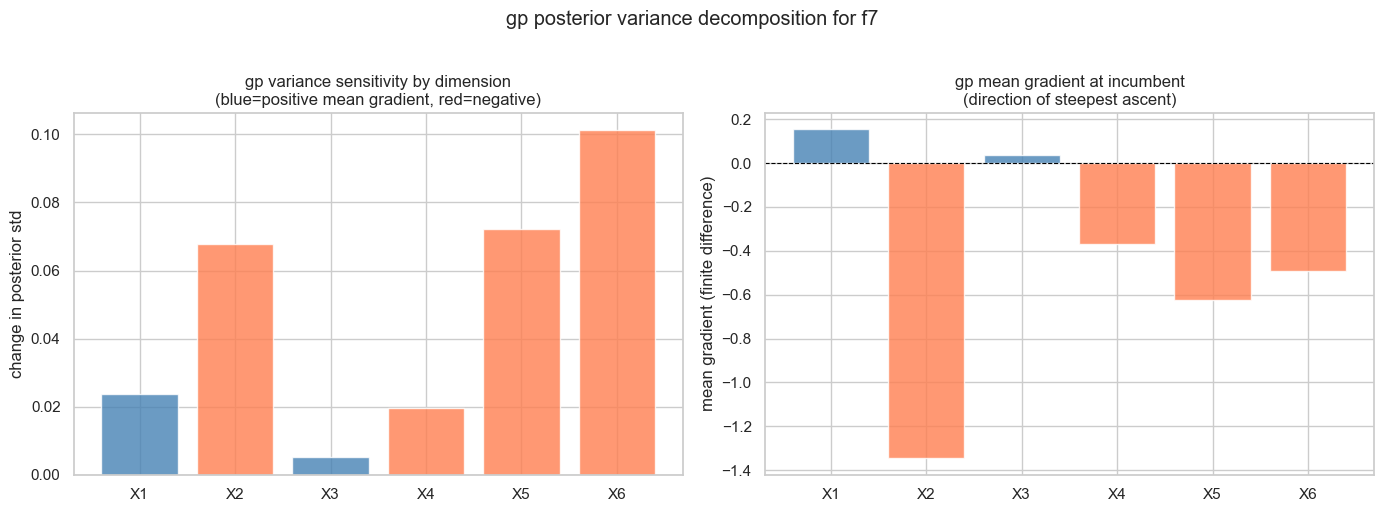

In [31]:
# method: gp posterior variance decomposition by dimension
# source: regularised.pdf and automl.pdf (ard kernel diagnostics)
# measures how much posterior variance changes when each dimension
# is perturbed from the incumbent by a fixed delta
# the dimension with largest variance change is most informative
# this directly catches the week 9 failure mode: high variance
# in x2 and x4 was in a low-y region, not near the peak
def gp_variance_decomposition(df, feature_cols, target_col, delta=0.05):
    """
    computes gp posterior variance decomposition by dimension.
    for each dimension, measures how much the posterior variance changes
    when the incumbent is perturbed by delta in that dimension.
    high sensitivity = gp is uncertain in that direction = informative to explore.
    cross-referenced with y values to distinguish high-uncertainty-high-y
    regions from high-uncertainty-low-y regions.

    parameters
    ----------
    df : dataframe containing features and target
    feature_cols : list of input column names
    target_col : output column name
    delta : perturbation size for finite difference (default 0.05)
    """

    X = df[feature_cols].values
    y = df[target_col].values
    n, d = X.shape

    # fit ard-gp on full dataset
    kernel = C(1.0, (1e-2, 1e2)) * Matern(
        length_scale=np.ones(d),
        length_scale_bounds=[(0.05, 5.0)] * d,
        nu=2.5
    ) + WhiteKernel(noise_level=1e-4, noise_level_bounds=(1e-6, 0.1))

    gp = GPR(kernel=kernel, normalize_y=True, n_restarts_optimizer=5)
    gp.fit(X, y)

    print("\ngp posterior variance decomposition")
    print(f"fitted kernel: {gp.kernel_}")

    # incumbent: point with highest observed y
    incumbent_idx = np.argmax(y)
    incumbent = X[incumbent_idx].copy()
    _, sigma_incumbent = gp.predict(incumbent.reshape(1, -1), return_std=True)
    print(f"\nincumbent: idx={incumbent_idx}, y={y[incumbent_idx]:.4f}")
    print(f"posterior std at incumbent: {sigma_incumbent[0]:.6f}")

    # variance sensitivity per dimension
    # for each dim j, perturb incumbent by +delta and -delta
    # record the change in posterior std
    var_sensitivity = np.zeros(d)
    mean_sensitivity = np.zeros(d)
    sigma_plus = np.zeros(d)
    sigma_minus = np.zeros(d)
    mu_plus = np.zeros(d)
    mu_minus = np.zeros(d)

    for j in range(d):
        x_plus = incumbent.copy()
        x_minus = incumbent.copy()
        x_plus[j] = np.clip(incumbent[j] + delta, 0.0, 1.0)
        x_minus[j] = np.clip(incumbent[j] - delta, 0.0, 1.0)

        mu_p, sig_p = gp.predict(x_plus.reshape(1, -1), return_std=True)
        mu_m, sig_m = gp.predict(x_minus.reshape(1, -1), return_std=True)

        sigma_plus[j] = sig_p[0]
        sigma_minus[j] = sig_m[0]
        mu_plus[j] = mu_p[0]
        mu_minus[j] = mu_m[0]

        # variance sensitivity: max change in std relative to incumbent std
        var_sensitivity[j] = max(
            abs(sig_p[0] - sigma_incumbent[0]),
            abs(sig_m[0] - sigma_incumbent[0])
        )
        mean_sensitivity[j] = (mu_p[0] - mu_m[0]) / (2 * delta + 1e-12)

    print("\nvariance sensitivity (change in posterior std per dimension):")
    print("high sensitivity = gp is most uncertain in this direction")
    for j, col in enumerate(feature_cols):
        print(f"  {col}: delta_sigma={var_sensitivity[j]:.6f}  "
              f"mean_grad={mean_sensitivity[j]:.4f}  "
              f"sigma+={sigma_plus[j]:.4f}  sigma-={sigma_minus[j]:.4f}")

    # rank dimensions by variance sensitivity
    rank_order = np.argsort(var_sensitivity)[::-1]
    print("\ndimensions ranked by variance sensitivity (most to least):")
    for rank, j in enumerate(rank_order):
        print(f"  rank {rank+1}: {feature_cols[j]} "
              f"(sensitivity={var_sensitivity[j]:.6f}, "
              f"mean_grad={mean_sensitivity[j]:.4f})")

    # plot variance decomposition
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    x_pos = np.arange(d)
    bar_colors = ["steelblue" if mean_sensitivity[j] > 0 else "coral"
                  for j in range(d)]

    axes[0].bar(x_pos, var_sensitivity[np.arange(d)],
                color=bar_colors, alpha=0.8)
    axes[0].set_xticks(x_pos)
    axes[0].set_xticklabels(feature_cols)
    axes[0].set_ylabel("change in posterior std")
    axes[0].set_title("gp variance sensitivity by dimension\n"
                      "(blue=positive mean gradient, red=negative)")

    # mean sensitivity plot
    colors_mean = ["steelblue" if v > 0 else "coral" for v in mean_sensitivity]
    axes[1].bar(x_pos, mean_sensitivity, color=colors_mean, alpha=0.8)
    axes[1].axhline(0, color="black", linewidth=0.8, linestyle="--")
    axes[1].set_xticks(x_pos)
    axes[1].set_xticklabels(feature_cols)
    axes[1].set_ylabel("mean gradient (finite difference)")
    axes[1].set_title("gp mean gradient at incumbent\n"
                      "(direction of steepest ascent)")

    plt.suptitle("gp posterior variance decomposition for f7", y=1.02)
    plt.tight_layout()
    plt.show()

    return var_sensitivity, mean_sensitivity, gp


var_sens_f7, mean_sens_f7, gp_f7 = gp_variance_decomposition(
    df_f7,
    feature_cols=["X1", "X2", "X3", "X4", "X5", "X6"],
    target_col="y1"
)

## Expected Improvement Contour Along Top-2 SIR Dimensions

**Reference:** Diessner, M., O'Connor, J., Wynn, A., Laizet, S., Gumerov, N., Agarwal, R. and Whalley, R.D. (2022) 'Investigating Bayesian optimization for expensive-to-evaluate black box functions: application in fluid dynamics', Frontiers in Applied Mathematics and Statistics, 8, article 1076296. Available at: https://doi.org/10.3389/fams.2022.1076296

- Used for f7 because the NUBO paper explicitly validates EI surface visualisation as a diagnostic for low-budget expensive function optimisation, and plotting the EI contour over the X1–X6 plane with all other dimensions fixed at the incumbent directly answers whether the next query should move X1 lower or X6 higher, the two dimensions with the strongest SIR loadings and the most consistent EDA signal across all eleven weeks.


expected improvement contour for f7
incumbent: idx=40, y=2.5822
sweeping X1 (dim 0) vs X6 (dim 5)
all other dimensions fixed at incumbent values

maximum ei at: X1=0.1017, X6=0.6780
ei value at maximum: 0.015994
gp mean at ei maximum: 2.5655


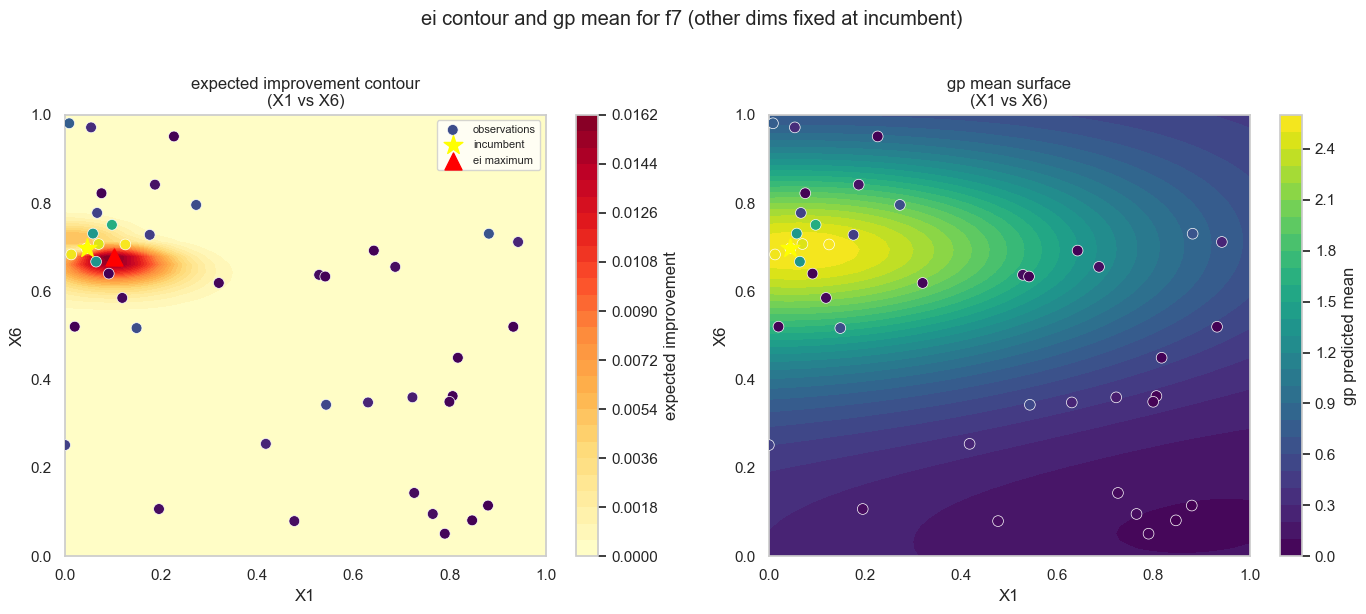


expected improvement contour for f7
incumbent: idx=40, y=2.5822
sweeping X1 (dim 0) vs X5 (dim 4)
all other dimensions fixed at incumbent values

maximum ei at: X1=0.1017, X5=0.3390
ei value at maximum: 0.009585
gp mean at ei maximum: 2.5743


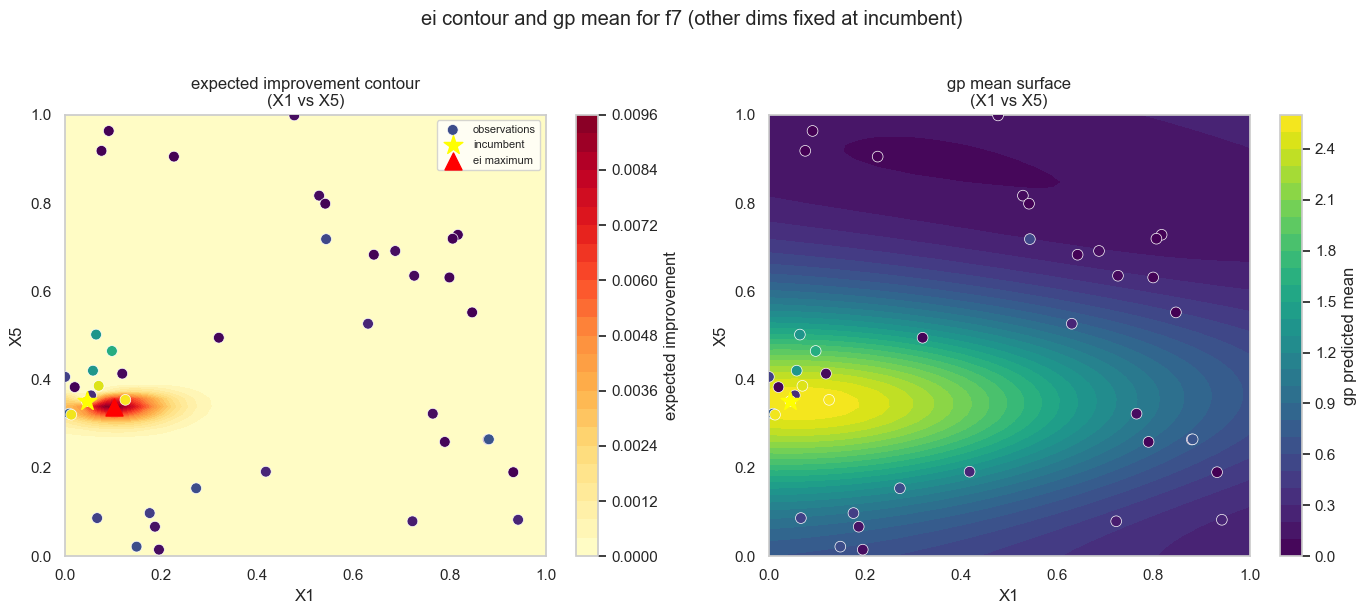

In [32]:
# method: expected improvement contour along top-2 sir dims
# source: fams081076296.pdf (nubo paper), which recommends ei surface
# visualisation for low-budget expensive function optimisation
# fixes all dimensions at incumbent values, sweeps top-2 sir dims
# produces a 2d heatmap showing where ei is highest near the peak
# directly answers: should x1 go lower, should x6 go higher

def ei_contour_plot(df, feature_cols, target_col,
                    dim1=0, dim2=5,
                    gp_fitted=None, n_grid=60):
    """
    plots the expected improvement contour along two selected dimensions.
    all other dimensions are fixed at the incumbent (current best) values.
    uses the already-fitted gp from variance decomposition if provided,
    otherwise fits a new one.

    parameters
    ----------
    df : dataframe containing features and target
    feature_cols : list of input column names
    target_col : output column name
    dim1 : index of first dimension to sweep (default 0 = x1)
    dim2 : index of second dimension to sweep (default 5 = x6)
    gp_fitted : already fitted gp (reuse to avoid refitting)
    n_grid : number of grid points per dimension (default 60)
    """

    from scipy.stats import norm as scipy_norm

    X = df[feature_cols].values
    y = df[target_col].values
    d = X.shape[1]

    # use fitted gp if provided, otherwise fit a new one
    if gp_fitted is None:
        kernel = C(1.0, (1e-2, 1e2)) * Matern(
            length_scale=np.ones(d),
            length_scale_bounds=[(0.05, 5.0)] * d,
            nu=2.5
        ) + WhiteKernel(noise_level=1e-4, noise_level_bounds=(1e-6, 0.1))
        gp = GPR(kernel=kernel, normalize_y=True, n_restarts_optimizer=5)
        gp.fit(X, y)
    else:
        gp = gp_fitted

    # incumbent: current best observed point
    incumbent_idx = np.argmax(y)
    incumbent = X[incumbent_idx].copy()
    y_best = y[incumbent_idx]

    print(f"\nexpected improvement contour for f7")
    print(f"incumbent: idx={incumbent_idx}, y={y_best:.4f}")
    print(f"sweeping {feature_cols[dim1]} (dim {dim1}) vs "
          f"{feature_cols[dim2]} (dim {dim2})")
    print(f"all other dimensions fixed at incumbent values")

    # create 2d grid over the two selected dimensions
    grid1 = np.linspace(0.0, 1.0, n_grid)
    grid2 = np.linspace(0.0, 1.0, n_grid)
    g1, g2 = np.meshgrid(grid1, grid2)

    # build candidate matrix: all other dims fixed at incumbent
    n_points = n_grid * n_grid
    X_grid = np.tile(incumbent, (n_points, 1))
    X_grid[:, dim1] = g1.ravel()
    X_grid[:, dim2] = g2.ravel()

    # gp posterior mean and std at grid points
    mu_grid, sigma_grid = gp.predict(X_grid, return_std=True)
    sigma_grid = np.maximum(sigma_grid, 1e-8)

    # expected improvement: ei(x) = sigma * [z * phi(z) + phi(z)]
    # where z = (mu - y_best) / sigma
    # this is the standard ei formula for maximisation
    z = (mu_grid - y_best) / sigma_grid
    ei_grid = sigma_grid * (z * scipy_norm.cdf(z) + scipy_norm.pdf(z))
    ei_grid = np.maximum(ei_grid, 0.0)

    ei_map = ei_grid.reshape(n_grid, n_grid)
    mu_map = mu_grid.reshape(n_grid, n_grid)

    # find grid point with maximum ei
    best_grid_idx = np.argmax(ei_grid)
    best_d1 = X_grid[best_grid_idx, dim1]
    best_d2 = X_grid[best_grid_idx, dim2]
    print(f"\nmaximum ei at: {feature_cols[dim1]}={best_d1:.4f}, "
          f"{feature_cols[dim2]}={best_d2:.4f}")
    print(f"ei value at maximum: {ei_grid[best_grid_idx]:.6f}")
    print(f"gp mean at ei maximum: {mu_grid[best_grid_idx]:.4f}")

    # plot ei contour and gp mean contour side by side
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # ei contour
    cf1 = axes[0].contourf(g1, g2, ei_map, levels=30, cmap="YlOrRd")
    plt.colorbar(cf1, ax=axes[0], label="expected improvement")
    axes[0].scatter(
        X[:, dim1], X[:, dim2],
        c=y, cmap="viridis", s=60, edgecolors="white", linewidths=0.5,
        zorder=5, label="observations"
    )
    axes[0].scatter(
        incumbent[dim1], incumbent[dim2],
        c="yellow", s=200, marker="*", zorder=6, label="incumbent"
    )
    axes[0].scatter(
        best_d1, best_d2,
        c="red", s=150, marker="^", zorder=6, label="ei maximum"
    )
    axes[0].set_xlabel(feature_cols[dim1])
    axes[0].set_ylabel(feature_cols[dim2])
    axes[0].set_title(f"expected improvement contour\n"
                      f"({feature_cols[dim1]} vs {feature_cols[dim2]})")
    axes[0].legend(fontsize=8)

    # gp mean contour
    cf2 = axes[1].contourf(g1, g2, mu_map, levels=30, cmap="viridis")
    plt.colorbar(cf2, ax=axes[1], label="gp predicted mean")
    axes[1].scatter(
        X[:, dim1], X[:, dim2],
        c=y, cmap="viridis", s=60, edgecolors="white", linewidths=0.5,
        zorder=5
    )
    axes[1].scatter(
        incumbent[dim1], incumbent[dim2],
        c="yellow", s=200, marker="*", zorder=6
    )
    axes[1].set_xlabel(feature_cols[dim1])
    axes[1].set_ylabel(feature_cols[dim2])
    axes[1].set_title(f"gp mean surface\n"
                      f"({feature_cols[dim1]} vs {feature_cols[dim2]})")

    plt.suptitle("ei contour and gp mean for f7 (other dims fixed at incumbent)",
                 y=1.02)
    plt.tight_layout()
    plt.show()

    return ei_grid, mu_grid, best_d1, best_d2


# run for the two highest sir loading dimensions: x1 (dim 0) and x6 (dim 5)
ei_f7, mu_f7, ei_best_x1, ei_best_x6 = ei_contour_plot(
    df_f7,
    feature_cols=["X1", "X2", "X3", "X4", "X5", "X6"],
    target_col="y1",
    dim1=0,   # x1: strongest sir loading
    dim2=5,   # x6: second strongest sir loading
    gp_fitted=gp_f7  # reuse the gp fitted in variance decomposition
)

# also run for x1 vs x5 to check the second most active dimension pair
ei_f7_x1x5, mu_f7_x1x5, ei_best_x1b, ei_best_x5 = ei_contour_plot(
    df_f7,
    feature_cols=["X1", "X2", "X3", "X4", "X5", "X6"],
    target_col="y1",
    dim1=0,   # x1
    dim2=4,   # x5: third strongest sir loading
    gp_fitted=gp_f7
)

#### f7 | Low-X2 Cluster Boundary Exploration with Structural Alignment Acquisition

In [33]:
# Separate inputs (X) and outputs (y)
X_train_7 = df_f7[[c for c in df_f7.columns if c.startswith("X")]].values
y_train_7 = df_f7["y1"].values
print(X_train_7)
print(y_train_7)

[[0.27262382 0.32449536 0.89710881 0.83295115 0.15406269 0.79586362]
 [0.54300258 0.9246939  0.34156746 0.64648585 0.71844033 0.34313266]
 [0.09083225 0.66152938 0.06593091 0.25857701 0.96345285 0.6402654 ]
 [0.11886697 0.61505494 0.90581639 0.8553003  0.41363143 0.58523563]
 [0.63021764 0.8380969  0.68001305 0.73189509 0.52673671 0.34842921]
 [0.76491917 0.25588292 0.60908422 0.21807904 0.32294277 0.09579366]
 [0.05789554 0.49167222 0.24742222 0.21811844 0.42042833 0.73096984]
 [0.19525188 0.07922665 0.55458046 0.17056682 0.01494418 0.10703171]
 [0.64230298 0.83687455 0.02179269 0.10148801 0.68307083 0.6924164 ]
 [0.78994255 0.19554501 0.57562333 0.07365919 0.25904917 0.05109986]
 [0.52849733 0.45742436 0.36009569 0.36204551 0.81689098 0.63747637]
 [0.72261522 0.01181284 0.06364591 0.16517311 0.07924415 0.35995166]
 [0.07566492 0.33450212 0.13273274 0.60831236 0.91838592 0.82233079]
 [0.94245084 0.37743962 0.48612233 0.22879108 0.08263175 0.71195755]
 [0.14864702 0.03394336 0.72880565

In [34]:
import numpy as np
from scipy.stats.qmc import Sobol
from sklearn.gaussian_process import GaussianProcessRegressor as GPR
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel as C
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor as KNN
from sklearn.model_selection import KFold
from xgboost import XGBRegressor as XGB


def propose_f7_query(X_train_7, y_train_7):
    """
    week 13 option 2: low-x2 exploration within the confirmed high-value cluster.

    rationale:
      the local linear gradient for x2 has been -0.680 (week 13) and -1.925
      (week 12) consistently. this is the steepest unvalidated direction in
      the cluster. no observation with x2 below 0.249 has ever been submitted
      within the high-value cluster neighbourhood. the gp cannot recommend
      this region because it has no data there to anchor a high mean prediction,
      but the local linear model built on the top-10 observations consistently
      points toward lower x2 as the direction of steepest improvement.

      this option accepts higher variance (the gp will predict moderate mean
      with high sigma) in exchange for testing the strongest unexplored signal.

    structural basis:
      x2 local linear gradient coefficient: -0.680 (steepest of x1, x3, x4, x6)
      x2 gp mean gradient at incumbent: -1.346 (second steepest after x5)
      x2 pearson correlation with y: -0.19 (consistent negative)
      x2 spearman: -0.22, kendall: -0.15 (all negative, all weeks)
      current minimum x2 in cluster: 0.249 (row 41)
      proposed x2 range: 0.15-0.23 (genuinely unsampled in this cluster)

    all other dimensions are anchored near the incumbent and top-3 observations
    to avoid compounding the x2 exploration with additional uncertainty in
    dimensions that are already well-characterised.
    """

    n_dims = X_train_7.shape[1]  # 6 for f7

    # step 1: define the target region
    # anchor point based on the incumbent and top-3 structural knowledge
    # only x2 is pushed into genuinely unsampled territory
    # all other dimensions stay within or near the top-3 empirical ranges

    incumbent_idx = np.argmax(y_train_7)
    incumbent = X_train_7[incumbent_idx].copy()
    y_best = float(y_train_7[incumbent_idx])

    top_k = 3
    top_indices = np.argsort(y_train_7)[-top_k:]
    top_X = X_train_7[top_indices]

    print(f"incumbent: idx={incumbent_idx}, y={y_best:.4f}")
    print(f"incumbent: {incumbent.round(4)}")
    print(f"\ntop-3 observations:")
    for idx in top_indices:
        print(f"  idx={idx}: X={X_train_7[idx].round(3)}, y={y_train_7[idx]:.4f}")

    # step 2: define the low-x2 exploration region
    # x2 target: [0.15, 0.24]
    #   lower bound 0.15: conservative floor, avoids extreme extrapolation
    #   upper bound 0.24: just below the current cluster minimum (0.249)
    #   this tests the direction without leaving the cluster manifold entirely
    # all other dimensions anchored near the top-3 ranges with a small margin
    # x1: [0.040, 0.130] covers the top-3 range with margin
    # x3: [0.530, 0.650] keeps x3 near the confirmed peak range
    # x4: [0.130, 0.230] keeps x4 low (partial r significant p=0.048)
    # x5: [0.330, 0.420] keeps x5 in the validated moderate range
    # x6: [0.670, 0.730] keeps x6 near the top-3 range

    region_lower = np.array([0.040, 0.150, 0.530, 0.130, 0.330, 0.670])
    region_upper = np.array([0.130, 0.240, 0.650, 0.230, 0.420, 0.730])

    print(f"\nlow-x2 exploration region:")
    dim_names = ["X1", "X2", "X3", "X4", "X5", "X6"]
    for i, name in enumerate(dim_names):
        print(f"  {name}: [{region_lower[i]:.3f}, {region_upper[i]:.3f}]")

    region_volume = np.prod(region_upper - region_lower)
    print(f"region volume: {region_volume:.8f}")

    # step 3: generate sobol candidates in the exploration region
    # 4096 candidates give dense coverage of the small region
    sampler = Sobol(d=n_dims, scramble=True, seed=131)
    unit_candidates = sampler.random_base2(m=12)
    candidates = region_lower + unit_candidates * (region_upper - region_lower)
    print(f"\ngenerated {len(candidates)} sobol candidates in low-x2 region")

    # step 4: distance guard
    # threshold 0.025: standard guard used across all exploitation weeks
    # ensures the selected point is genuinely novel and not a near-duplicate
    # of any existing observation, including the cluster members
    dist_threshold = 0.025
    dists = np.array([
        np.min(np.linalg.norm(X_train_7 - c, axis=1))
        for c in candidates
    ])
    candidates_filtered = candidates[dists >= dist_threshold]
    print(f"candidates after distance guard (threshold={dist_threshold}): "
          f"{len(candidates_filtered)}")

    if len(candidates_filtered) < 20:
        # relax guard if too few survive
        candidates_filtered = candidates[dists >= 0.015]
        print(f"guard relaxed to 0.015: {len(candidates_filtered)} candidates")

    candidates = candidates_filtered

    # step 5: fit ard-gp
    # the gp here is expected to have high sigma in the low-x2 region because
    # it has no training data there. the gp mean will likely be moderate (~1.5-2.0)
    # because it is extrapolating from the cluster boundary. this is acceptable --
    # the goal is not to follow the gp mean but to use the gp as a relative
    # ranking tool within the low-x2 region to find the best combination of
    # x1, x3, x4, x5, x6 given the x2 exploration constraint
    kernel_gp = C(1.0, (1e-2, 1e2)) * Matern(
        length_scale=np.ones(n_dims),
        length_scale_bounds=[(0.05, 5.0)] * n_dims,
        nu=2.5,
    ) + WhiteKernel(noise_level=1e-4, noise_level_bounds=(1e-6, 0.1))

    gp = GPR(kernel=kernel_gp, normalize_y=True, n_restarts_optimizer=10)
    gp.fit(X_train_7, y_train_7)

    print(f"\nfitted kernel: {gp.kernel_}")

    mu_gp, sigma_gp = gp.predict(candidates, return_std=True)
    sigma_gp = np.maximum(sigma_gp, 1e-8)

    print(f"gp mean range in low-x2 region: "
          f"[{mu_gp.min():.4f}, {mu_gp.max():.4f}]")
    print(f"gp sigma range in low-x2 region: "
          f"[{sigma_gp.min():.4f}, {sigma_gp.max():.4f}]")

    # step 6: four-model ensemble for local ranking
    # the ensemble provides a second opinion within the low-x2 region
    # knn and xgb will extrapolate from the nearest cluster members
    # svr and gp provide smoother interpolation
    # cv weighting ensures the most reliable model dominates
    kernel_ens = C(1.0, (1e-2, 1e2)) * Matern(
        length_scale=np.ones(n_dims),
        length_scale_bounds=[(1e-2, 1e2)] * n_dims,
        nu=2.5,
    )
    gp_ens = GPR(kernel=kernel_ens, normalize_y=True, n_restarts_optimizer=5)
    svr = SVR(C=5.0, epsilon=0.1, kernel="rbf")
    knn = KNN(n_neighbors=4, weights="distance")
    xgb = XGB(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        verbosity=0,
    )
    models = [gp_ens, svr, knn, xgb]
    model_names = ["gp", "svr", "knn", "xgb"]

    # 5-fold cv weighting: validated configuration across weeks 6-13
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    cv_errors = []
    for model in models:
        fold_errors = []
        for train_idx, test_idx in kf.split(X_train_7):
            X_tr, X_te = X_train_7[train_idx], X_train_7[test_idx]
            y_tr, y_te = y_train_7[train_idx], y_train_7[test_idx]
            model.fit(X_tr, y_tr)
            preds = model.predict(X_te)
            fold_errors.append(np.mean((preds - y_te) ** 2))
        cv_errors.append(np.mean(fold_errors))

    cv_errors = np.array(cv_errors)
    inv_errors = 1.0 / (cv_errors + 1e-8)
    ens_weights = inv_errors / np.sum(inv_errors)

    print(f"\ncv errors:        {dict(zip(model_names, cv_errors.round(4)))}")
    print(f"ensemble weights: {dict(zip(model_names, ens_weights.round(4)))}")

    for model in models:
        model.fit(X_train_7, y_train_7)

    preds_ens = np.column_stack([m.predict(candidates) for m in models])
    mean_ens = preds_ens.dot(ens_weights)
    var_ens = np.var(preds_ens, axis=1)
    var_inflated = 3.0 * var_ens

    # ensemble acquisition: same validated formula as weeks 6, 10, 11, 12, 13
    acq_ens = mean_ens + 1.5 * var_inflated

    # step 7: combine gp ucb and ensemble for final scoring
    # within the low-x2 region the gp sigma is large (extrapolation territory)
    # ucb with high beta exploits both mean and uncertainty signal
    # beta=3.0 maintains strong exploration within the constrained region
    # this rewards points that are both predicted high and uncertain
    # which is the correct acquisition behaviour when exploring genuinely
    # unsampled territory within a known high-value neighbourhood
    beta_ucb = 3.0
    acq_gp_ucb = mu_gp + beta_ucb * sigma_gp

    # normalise both acquisition signals to [0,1]
    def normalise(arr):
        r = arr.max() - arr.min()
        if r > 1e-10:
            return (arr - arr.min()) / r
        return np.ones(len(arr))

    acq_gp_norm = normalise(acq_gp_ucb)
    acq_ens_norm = normalise(acq_ens)

    # equal weight: gp ucb and ensemble both contribute 0.50
    # unlike the exploitation weeks where ensemble dominated (0.60-0.70),
    # here the gp sigma is the most informative signal in uncharted territory
    # equal weighting prevents the ensemble from over-exploiting a region
    # where knn and xgb are extrapolating unreliably
    acq_combined = 0.50 * acq_gp_norm + 0.50 * acq_ens_norm

    # step 8: structural alignment boost
    # within the low-x2 region, reward combinations that align with the
    # top-3 observations on all dimensions except x2
    # this prevents the acquisition from selecting a low-x2 point that is
    # also wrong on x1, x4, x5, x6 simultaneously
    struct_boost = np.ones(len(candidates))

    # x1 reward: [0.050, 0.110] covers all three top observations with margin
    x1_vals = candidates[:, 0]
    struct_boost *= np.where((x1_vals >= 0.050) & (x1_vals <= 0.110), 1.12,
                   np.where((x1_vals >= 0.035) & (x1_vals <= 0.130), 1.05, 1.0))

    # x2 reward: lower is the whole point of this option
    # reward x2 in [0.15, 0.21] most strongly (furthest from sampled region)
    x2_vals = candidates[:, 1]
    struct_boost *= np.where(x2_vals <= 0.19, 1.15,
                   np.where(x2_vals <= 0.22, 1.08, 1.0))

    # x3 reward: [0.55, 0.63] consistent with top-3 and corrects week 12 failure
    x3_vals = candidates[:, 2]
    struct_boost *= np.where((x3_vals >= 0.55) & (x3_vals <= 0.63), 1.10, 1.0)

    # x4 reward: low x4 preferred (partial r significant p=0.048)
    x4_vals = candidates[:, 3]
    struct_boost *= np.where(x4_vals <= 0.170, 1.10,
                   np.where(x4_vals <= 0.210, 1.05, 1.0))

    # x5 reward: moderate x5 in [0.35, 0.40] validated by local linear gradient
    x5_vals = candidates[:, 4]
    struct_boost *= np.where((x5_vals >= 0.350) & (x5_vals <= 0.400), 1.10,
                   np.where(x5_vals < 0.330, 0.93, 1.0))

    # x6 reward: [0.685, 0.720] consistent with top-3 range
    x6_vals = candidates[:, 5]
    struct_boost *= np.where((x6_vals >= 0.685) & (x6_vals <= 0.720), 1.10,
                   np.where(x6_vals < 0.660, 0.93, 1.0))

    # normalise boost to [0.88, 1.12]
    sb_min, sb_max = struct_boost.min(), struct_boost.max()
    if sb_max > sb_min:
        struct_boost = 0.88 + 0.24 * (struct_boost - sb_min) / (sb_max - sb_min)

    acq_final = acq_combined * struct_boost

    # step 9: select best candidate
    best_idx = np.argmax(acq_final)
    next_x = candidates[best_idx]

    next_preds = np.array([m.predict(next_x.reshape(1, -1))[0] for m in models])
    predicted_y_ens = float(next_preds.dot(ens_weights))
    predicted_y_gp = float(gp.predict(next_x.reshape(1, -1))[0])
    predicted_sigma = float(gp.predict(next_x.reshape(1, -1), return_std=True)[1][0])

    # step 10: diagnostics
    min_dist = float(np.min(np.linalg.norm(X_train_7 - next_x, axis=1)))
    sir_direction = np.array([-0.5293, -0.1801, 0.3412, -0.3174, -0.5159, 0.4518])
    sir_score = float(next_x.dot(sir_direction))
    incumbent_sir = float(incumbent.dot(sir_direction))

    print(f"\nweek 13: low-x2 exploration")
    print(f"selected point:          {next_x}")
    print(f"predicted y (ensemble):  {predicted_y_ens:.6f}")
    print(f"predicted y (gp mean):   {predicted_y_gp:.6f}")
    print(f"predicted sigma (gp):    {predicted_sigma:.6f}")
    print(f"sir score: {sir_score:.4f}  (incumbent: {incumbent_sir:.4f})")
    print(f"x1: {next_x[0]:.4f}  (top-3 range: 0.045-0.125)")
    print(f"x2: {next_x[1]:.4f}  (cluster minimum was 0.249, this is unsampled)")
    print(f"x3: {next_x[2]:.4f}  (target: 0.55-0.63)")
    print(f"x4: {next_x[3]:.4f}  (target: low, partial r significant)")
    print(f"x5: {next_x[4]:.4f}  (target: 0.35-0.40)")
    print(f"x6: {next_x[5]:.4f}  (target: 0.685-0.720)")
    print(f"min dist to training:    {min_dist:.4f}")
    print(f"current best y:          {y_best:.6f}")

    # report x2 gap from nearest cluster observation
    cluster_min_x2 = np.min(
        X_train_7[np.argsort(y_train_7)[-5:], 1]
    )
    print(f"\nx2 gap below cluster minimum: "
          f"{cluster_min_x2:.4f} - {next_x[1]:.4f} = "
          f"{cluster_min_x2 - next_x[1]:.4f}")
    print(f"this is genuinely uncharted territory for x2 within this cluster")

    # sanity checks
    assert min_dist >= 0.015, f"distance guard violated: {min_dist:.4f}"
    assert next_x[1] < 0.245, f"x2 target violated: x2={next_x[1]:.4f}"
    assert next_x[2] >= 0.52, f"x3 floor violated: x3={next_x[2]:.4f}"
    assert next_x[4] >= 0.32, f"x5 floor violated: x5={next_x[4]:.4f}"

    return next_x, predicted_y_ens, ens_weights


next_x, predicted_y, ens_weights = propose_f7_query(
    X_train_7, y_train_7
)

incumbent: idx=40, y=2.5822
incumbent: [0.0448 0.3015 0.6105 0.2519 0.3515 0.6975]

top-3 observations:
  idx=41: X=[0.013 0.268 0.503 0.173 0.321 0.684], y=2.5219
  idx=39: X=[0.125 0.293 0.563 0.153 0.354 0.706], y=2.5580
  idx=40: X=[0.045 0.302 0.61  0.252 0.352 0.697], y=2.5822

low-x2 exploration region:
  X1: [0.040, 0.130]
  X2: [0.150, 0.240]
  X3: [0.530, 0.650]
  X4: [0.130, 0.230]
  X5: [0.330, 0.420]
  X6: [0.670, 0.730]
region volume: 0.00000052

generated 4096 sobol candidates in low-x2 region
candidates after distance guard (threshold=0.025): 4096

fitted kernel: 0.635**2 * Matern(length_scale=[0.674, 0.321, 5, 0.712, 0.214, 0.233], nu=2.5) + WhiteKernel(noise_level=1e-06)
gp mean range in low-x2 region: [2.0744, 2.5658]
gp sigma range in low-x2 region: [0.0598, 0.2415]

cv errors:        {'gp': 0.1884, 'svr': 0.2209, 'knn': 0.4346, 'xgb': 0.2555}
ensemble weights: {'gp': 0.3307, 'svr': 0.2821, 'knn': 0.1434, 'xgb': 0.2439}

week 13: low-x2 exploration
selected point:  